# Buffett's Alpha A股：大盘定义（已锁定）
大盘 = 总市值>300亿 + 300亿内近60日累计成交金额前300 + 近7日均成交金额≥2亿。金额≈close×volume；仅用≤D数据；D无成交判不可交易。

In [1]:
import os, sys, warnings
import pandas as pd, numpy as np
warnings.filterwarnings('ignore')
_ROOT=os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_ROOT,'scripts','graham_dodd_lib.py')): break
    _ROOT=os.path.dirname(_ROOT)
os.chdir(_ROOT); sys.path.insert(0, os.path.join(_ROOT,'scripts'))
from graham_dodd_lib import load_universe, load_market, snapshot
CAP_FLOOR=300e8; AMT7_FLOOR=2e8; D=pd.Timestamp('2024-07-01')
def amounts(code,D):
    m=load_market(code)
    if m is None or D not in m.index: return np.nan,np.nan
    w=m.loc[:D].tail(60); a=w['close']*w['volume']
    return a.sum(), a.tail(7).mean()
uni=load_universe(); rows=[]; fun={'n':len(uni),'notrad':0,'cap':0}
for code in uni['code']:
    s=snapshot(code,D)
    if not s.tradable or not np.isfinite(s.market_cap): fun['notrad']+=1; continue
    if s.market_cap<CAP_FLOOR: fun['cap']+=1; continue
    a60,a7=amounts(code,D)
    rows.append((code,s.name,s.industry,s.market_cap,a60,a7))
df=pd.DataFrame(rows,columns=['code','name','industry','cap','amt60','amt7']).dropna()
df=df[df['amt7']>=AMT7_FLOOR].sort_values('amt60',ascending=False).head(300)
print(D.date(),fun,'大盘=',len(df)); df.head(10)

2024-07-01 {'n': 5904, 'notrad': 1865, 'cap': 3731} 大盘= 237


,code,name,industry,cap,amt60,amt7
36,000906,浙商中拓,商业百货,2.605545e+12,6.116405e+15,7.884892e+13
35,000905,厦门港务,交通运输,3.711393e+12,3.910298e+15,4.712859e+13
195,600519,贵州茅台,酿酒行业,1.809402e+12,3.006404e+11,5.949534e+09
249,601127,赛力斯,,1.393982e+11,2.555572e+11,5.496070e+09
250,601138,工业富联,,5.561928e+11,2.369668e+11,3.166507e+09
125,300750,宁德时代,,7.745392e+11,2.313485e+11,3.144597e+09
112,300308,中际旭创,机械行业,1.163295e+11,2.162095e+11,3.336146e+09
289,601899,紫金矿业,有色金属,4.748263e+10,1.967528e+11,2.144235e+09
298,603259,药明康德,,1.134025e+11,1.866698e+11,1.297667e+09
91,002594,比亚迪,汽车制造,7.184701e+11,1.794872e+11,3.001779e+09


## 便宜定义（已锁定）：大盘内 E/P+B/P+D/P 等权z + 硬门E/P>0.02(PE<50)且B/P<2(PB>0.5) + 周期排除（含未知行业）；D/P只打分不设门
周期表复用 magic_formula_lib.CYCLICAL_INDUSTRIES；亏损/无分红直接落选。

In [2]:
from magic_formula_lib import CYCLICAL_INDUSTRIES
def _z(s): r=s.rank(method='min'); return (r-r.mean())/r.std()
def value_rank(D, codes):
    rows=[]; fun={'cyc':0,'neg':0,'cheap':0}
    for code in codes:
        s=snapshot(code,D)
        if not s.industry or s.industry in CYCLICAL_INDUSTRIES: fun['cyc']+=1; continue
        if not(np.isfinite(s.eps_ttm) and s.eps_ttm>0 and np.isfinite(s.bvps) and s.bvps>0): fun['neg']+=1; continue
        ep=s.eps_ttm/s.price; bp=s.bvps/s.price
        if not(ep>0.02 and bp<2): fun['cheap']+=1; continue
        dp=s.dividend_yield if np.isfinite(s.dividend_yield) else 0.0
        rows.append((code,s.name,s.industry,ep,bp,dp))
    v=pd.DataFrame(rows,columns=['code','name','industry','ep','bp','dp'])
    v['value_z']=(_z(v['ep'])+_z(v['bp'])+_z(v['dp']))/3
    return v.sort_values('value_z',ascending=False).reset_index(drop=True), fun
val,vfun=value_rank(D, df['code']); print('价值池=',len(val),vfun); val.head(10)

价值池= 103 {'cyc': 104, 'neg': 8, 'cheap': 22}


,code,name,industry,ep,bp,dp,value_z
0,600048,保利发展,房地产,0.166094,1.794883,0.048335,1.628872
1,002459,晶澳科技,机械行业,0.197836,0.933537,0.050044,1.573089
2,600256,广汇能源,综合行业,0.270504,0.664216,0.102489,1.539619
3,601607,上海医药,商业百货,0.081981,0.976201,0.031476,1.394582
4,000661,长春高新,生物制药,0.102260,0.605112,0.048237,1.338799
5,601012,隆基绿能,电子器件,0.148257,0.640047,0.028470,1.271859
6,600863,华能蒙电,电力行业,0.068950,0.624324,0.034599,1.216076
7,002304,洋河股份,酿酒行业,0.083707,0.477838,0.057845,1.160292
8,000651,格力电器,家电行业,0.112354,0.554776,0.025707,1.071039
9,000625,长安汽车,汽车制造,0.075979,0.543685,0.025258,0.970629


In [3]:
dys=pd.Series({c: snapshot(c,D).dividend_yield for c in df['code']})
print(dys.describe(percentiles=[.1,.25,.5,.75,.9]).round(4))
print('>4%:',int((dys>0.04).sum()),'>3%:',int((dys>0.03).sum()),'缺失:',int(dys.isna().sum()))
print(val[['code','name','industry','ep','bp','dp','value_z']].to_string(index=False))

count    219.0000
mean       0.0210
std        0.0181
min        0.0000
10%        0.0038
25%        0.0086
50%        0.0170
75%        0.0264
90%        0.0455
max        0.1129
dtype: float64
>4%: 28 >3%: 42 缺失: 18
  code  name industry       ep       bp       dp   value_z
600048  保利发展      房地产 0.166094 1.794883 0.048335  1.628872
002459  晶澳科技     机械行业 0.197836 0.933537 0.050044  1.573089
600256  广汇能源     综合行业 0.270504 0.664216 0.102489  1.539619
601607  上海医药     商业百货 0.081981 0.976201 0.031476  1.394582
000661  长春高新     生物制药 0.102260 0.605112 0.048237  1.338799
601012  隆基绿能     电子器件 0.148257 0.640047 0.028470  1.271859
600863  华能蒙电     电力行业 0.068950 0.624324 0.034599  1.216076
002304  洋河股份     酿酒行业 0.083707 0.477838 0.057845  1.160292
000651  格力电器     家电行业 0.112354 0.554776 0.025707  1.071039
000625  长安汽车     汽车制造 0.075979 0.543685 0.025258  0.970629
600089  特变电工     发电设备 0.248476 0.937861 0.014327  0.959473
600060  海信视像     家电行业 0.061053 0.583369 0.025647  0.948316
000999  华润三九   

## 三支柱宽松硬门（已锁定）：便宜 E/P>0.02且B/P<2；安全 收缩Beta<1.5；质量 股息>3%或ROE>10%
周期/未知行业排除保留；过了门再加权打分倒排。

In [4]:
from graham_dodd_lib import load_index
midx=load_index('000300'); mr=np.log(midx['close']/midx['close'].shift(1))
def beta_of(code,D):
    m=load_market(code)
    if m is None or D not in m.index: return np.nan
    w=m.loc[:D].tail(260); r=np.log(w['close']/w['close'].shift(1)).dropna()
    a=r.index.intersection(mr.index)
    if len(a)<120: return np.nan
    return 0.6*np.cov(r.loc[a],mr.loc[a])[0,1]/mr.loc[a].var()+0.4


In [5]:
BETA_MAX=1.5; QROE=0.10; QDIV=0.03
rows=[]; fun={'cyc':0,'neg':0,'cheap':0,'beta':0,'qual':0}
for code in df['code']:
    s=snapshot(code,D)
    if not s.industry or s.industry in CYCLICAL_INDUSTRIES: fun['cyc']+=1; continue
    if not(np.isfinite(s.eps_ttm) and s.eps_ttm>0 and np.isfinite(s.bvps) and s.bvps>0): fun['neg']+=1; continue
    if not(s.eps_ttm/s.price>0.02 and s.bvps/s.price<2): fun['cheap']+=1; continue
    be=beta_of(code,D)
    if not np.isfinite(be) or be>=BETA_MAX: fun['beta']+=1; continue
    roe=s.eps_ttm/s.bvps; div=s.dividend_yield
    if not((np.isfinite(div) and div>QDIV) or roe>QROE): fun['qual']+=1; continue
    rows.append((code,s.name,s.industry,s.eps_ttm/s.price,s.bvps/s.price,div if np.isfinite(div) else 0,roe,be))
pool=pd.DataFrame(rows,columns=['code','name','industry','ep','bp','dp','roe','beta'])
print('三门后=',len(pool),fun)

三门后= 63 {'cyc': 104, 'neg': 8, 'cheap': 22, 'beta': 8, 'qual': 32}


In [6]:
# 合成(已锁定): composite=(value_z+safe_z+quality_z)/3, quality_z=(zROE+zTTM yoy+zD/P)/3
pool['qyoy']=[snapshot(c,D).ttm_yoy for c in pool['code']]
pool['value_z']=(_z(pool['ep'])+_z(pool['bp'])+_z(pool['dp']))/3
pool['safe_z']=-_z(pool['beta'])
pool['quality_z']=(_z(pool['roe'])+_z(pool['qyoy'])+_z(pool['dp']))/3
pool['composite']=(pool['value_z']+pool['safe_z']+pool['quality_z'])/3
top30=pool.sort_values('composite',ascending=False).head(30).reset_index(drop=True)
print(top30[['code','name','industry','composite','value_z','safe_z','quality_z']].to_string(index=False))

  code  name industry  composite   value_z    safe_z  quality_z
600256  广汇能源     综合行业   1.188075  1.563895  0.436436   1.563895
600863  华能蒙电     电力行业   1.042597  1.109274  1.527525   0.490990
600642  申能股份     电力行业   0.854687  0.654654  1.582080   0.327327
000333  美的集团     家电行业   0.848625  0.854687  1.309307   0.381881
000408  藏格矿业     商业百货   0.818317  0.818317  0.218218   1.418416
000999  华润三九     生物制药   0.818317  0.854687  1.472971   0.127294
000651  格力电器     家电行业   0.763763  0.963796  1.091089   0.236403
601607  上海医药     商业百货   0.745578  1.218383  1.036535  -0.018185
600887  伊利股份     食品行业   0.612222  0.709208  0.927426   0.200033
600660  福耀玻璃     汽车制造   0.563730 -0.090924  1.363862   0.418251
600089  特变电工     发电设备   0.563730  0.836502  0.109109   0.745578
600674  川投能源     电力行业   0.478867  0.127294  1.636634  -0.327327
600060  海信视像     家电行业   0.466744  0.763763  0.545545   0.090924
002459  晶澳科技     机械行业   0.466744  1.527525 -1.582080   1.454786
002304  洋河股份     酿酒行业   0.460682  1.1820

In [7]:
# select_topN: 大盘+三门+合成+行业≤5, 供回测多期复用
N_TOP=20; IND_CAP=5
def select_topN(D, n=N_TOP):
    lc=[]
    for code in load_universe()['code']:
        s=snapshot(code,D)
        if not s.tradable or not np.isfinite(s.market_cap) or s.market_cap<CAP_FLOOR: continue
        a60,a7=amounts(code,D)
        if np.isfinite(a7) and a7>=AMT7_FLOOR: lc.append((code,a60))
    codes=[c for c,_ in sorted(lc,key=lambda x:-x[1])[:300]]
    rows=[]
    for code in codes:
        s=snapshot(code,D)
        if not s.industry or s.industry in CYCLICAL_INDUSTRIES: continue
        if not(np.isfinite(s.eps_ttm) and s.eps_ttm>0 and np.isfinite(s.bvps) and s.bvps>0): continue
        ep=s.eps_ttm/s.price; bp=s.bvps/s.price
        if not(ep>0.02 and bp<2): continue
        be=beta_of(code,D)
        if not np.isfinite(be) or be>=BETA_MAX: continue
        roe=s.eps_ttm/s.bvps; dp=s.dividend_yield if np.isfinite(s.dividend_yield) else 0.0
        if not(dp>QDIV or roe>QROE): continue
        rows.append((code,s.name,s.industry,ep,bp,dp,roe,be))
    p=pd.DataFrame(rows,columns=['code','name','industry','ep','bp','dp','roe','beta'])
    p['qyoy']=[snapshot(c,D).ttm_yoy for c in p['code']]
    p['value_z']=(_z(p['ep'])+_z(p['bp'])+_z(p['dp']))/3
    p['safe_z']=-_z(p['beta'])
    p['quality_z']=(_z(p['roe'])+_z(p['qyoy'])+_z(p['dp']))/3
    p['composite']=(p['value_z']+p['safe_z']+p['quality_z'])/3
    p=p.sort_values('composite',ascending=False)
    out=[]; cnt={}
    for _,r in p.iterrows():
        if cnt.get(r['industry'],0)>=IND_CAP: continue
        out.append(r); cnt[r['industry']]=cnt.get(r['industry'],0)+1
        if len(out)>=n: break
    return pd.DataFrame(out)
top20=select_topN(D); print(len(top20)); print(top20[['code','name','industry','composite']].to_string(index=False))

20
  code name industry  composite
600256 广汇能源     综合行业   1.188075
600863 华能蒙电     电力行业   1.042597
600642 申能股份     电力行业   0.854687
000333 美的集团     家电行业   0.848625
000408 藏格矿业     商业百货   0.818317
000999 华润三九     生物制药   0.818317
000651 格力电器     家电行业   0.763763
601607 上海医药     商业百货   0.745578
600887 伊利股份     食品行业   0.612222
600660 福耀玻璃     汽车制造   0.563730
600089 特变电工     发电设备   0.563730
600674 川投能源     电力行业   0.478867
600060 海信视像     家电行业   0.466744
002459 晶澳科技     机械行业   0.466744
002304 洋河股份     酿酒行业   0.460682
000661 长春高新     生物制药   0.363696
002422 科伦药业     生物制药   0.357635
000921 海信家电     家电行业   0.351573
000538 云南白药     生物制药   0.351573
600900 长江电力     电力行业   0.339450


In [8]:
# 回测引擎v1: 50万,NAV5%建仓,D+1成交,日度10%砍回5%,季度全换(本cell先跑单季度验证)
from graham_dodd_lib import Pos, buy_fee, sell_fee, trading_days
from graham_dodd_lib import GrahamBacktest as GB
CAL=trading_days()
def nxt(d): return pd.Timestamp(CAL[CAL>d][0])
D0=pd.Timestamp('2024-07-01'); T0=nxt(D0); Q1=pd.Timestamp(CAL[CAL>=pd.Timestamp('2024-10-01')][0])
picks=select_topN(D0)
cash=500000.0; poss={}; nav0=cash
for _,r in picks.iterrows():
    m=load_market(r['code'])
    if m is None or T0 not in m.index: continue
    p=float(m.loc[T0,'close']); sh=int(nav0*0.05/p/100)*100
    if sh<=0: continue
    amt=sh*p; cash-=amt+buy_fee(amt)
    poss[r['code']]=Pos(r['code'],r['name'],sh,p,amt,p,T0)
trims=0; navs={}
for t in CAL[(CAL>=T0)&(CAL<=Q1)]:
    tot=cash; mvs={}
    for code,pos in poss.items():
        mv,dv=GB._position_value(pos,t); mvs[code]=mv; tot+=mv+dv
    for code,pos in list(poss.items()):
        if mvs[code]/tot>0.10:
            m=load_market(code); prev=m.index[m.index<=t]
            if not len(prev): continue
            p=float(m.loc[prev[-1],'close']); sh=int((mvs[code]-tot*0.05)/p/100)*100
            if sh<=0: continue
            proc=sh*p; cash+=proc-sell_fee(t,proc); pos.shares-=sh; trims+=1
    navs[t]=tot
nav=pd.Series(navs)
print('建仓',len(poss),'只 trims=',trims,'起始%.0f 期末%.0f 收益%.2f%%'%(nav.iloc[0],nav.iloc[-1],nav.iloc[-1]/nav.iloc[0]*100-100))

建仓 20 只 trims= 0 起始499856 期末568366 收益13.71%


In [9]:
# 全量回测: 2023-07-01~2026-09-19, 季度信号D+1全换, 并行选股
import multiprocessing as mp
START=pd.Timestamp('2023-07-01'); HARD_END=min(pd.Timestamp('2026-09-19'),CAL.max())
qs=[]; q=START
while q<=HARD_END:
    s=CAL[CAL>=q]
    if len(s): qs.append(pd.Timestamp(s[0]))
    q=(pd.Timestamp(year=q.year,month=q.month,day=1)+pd.DateOffset(months=3))
print('调仓日:',[d.date().isoformat() for d in qs])
with mp.get_context('fork').Pool(8) as pool:
    maps=pool.map(select_topN, qs)
print('各期入选:',[len(m) for m in maps])
cash=500000.0; poss={}; navs={}; ntrim=0
for i,D in enumerate(qs):
    T=nxt(D); Q1=qs[i+1] if i+1<len(qs) else HARD_END
    for code,pos in list(poss.items()):
        liq=GB._liquidation_value(pos,T); cash+=liq-sell_fee(T,liq); poss.pop(code)
    tot0=cash
    for _,r in maps[i].iterrows():
        m=load_market(r['code'])
        if m is None or T not in m.index: continue
        p=float(m.loc[T,'close']); sh=int(tot0*0.05/p/100)*100
        if sh<=0: continue
        amt=sh*p; cash-=amt+buy_fee(amt)
        poss[r['code']]=Pos(r['code'],r['name'],sh,p,amt,p,T)
    for t in CAL[(CAL>=T)&(CAL<=Q1)]:
        tot=cash; mvs={}
        for code,pos in poss.items():
            mv,dv=GB._position_value(pos,t); mvs[code]=mv; tot+=mv+dv
        for code,pos in list(poss.items()):
            if mvs[code]/tot>0.10:
                m=load_market(code); prev=m.index[m.index<=t]
                if not len(prev): continue
                p=float(m.loc[prev[-1],'close']); sh=int((mvs[code]-tot*0.05)/p/100)*100
                if sh<=0: continue
                proc=sh*p; cash+=proc-sell_fee(t,proc); pos.shares-=sh; ntrim+=1
        navs[t]=tot
nav=pd.Series(navs)
print('期末%.0f trims=%d'%(nav.iloc[-1],ntrim))

调仓日: ['2023-07-03', '2023-10-09', '2024-01-02', '2024-04-01', '2024-07-01', '2024-10-08', '2025-01-02', '2025-04-01', '2025-07-01', '2025-10-09', '2026-01-05', '2026-04-01', '2026-07-01']
各期入选: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
期末424599 trims=0


In [10]:
sys.path.insert(0,_ROOT)
from analysis.performance import performance_summary
print(performance_summary(nav.pct_change().dropna(),nav))
b60=load_index('000300')['close'].reindex(nav.index).ffill()
b80=load_index('000906')['close'].reindex(nav.index).ffill()
cmp=pd.DataFrame({'策略':nav,'沪深300':b60/b60.iloc[0]*nav.iloc[0],'中证800':b80/b80.iloc[0]*nav.iloc[0]})
print(cmp.iloc[[0,len(cmp)//2,-1]].round(0))

{'annual_return': np.float64(-0.05128723596194129), 'annual_vol': np.float64(0.14540149399752422), 'sharpe': np.float64(-0.49027856593519675), 'sortino': np.float64(-0.7047353960587304), 'calmar': np.float64(-0.2976580062228135), 'max_drawdown': np.float64(-0.23949376288094482), 'win_rate': np.float64(0.4647887323943662), 'cumulative_return': np.float64(-0.15055384996253296), 'rf_used': 0.02}
                  策略     沪深300     中证800
2023-07-04  499854.0  499854.0  499854.0
2025-02-17  471147.0  506057.0  502053.0
2026-09-18  424599.0  577848.0  614323.0


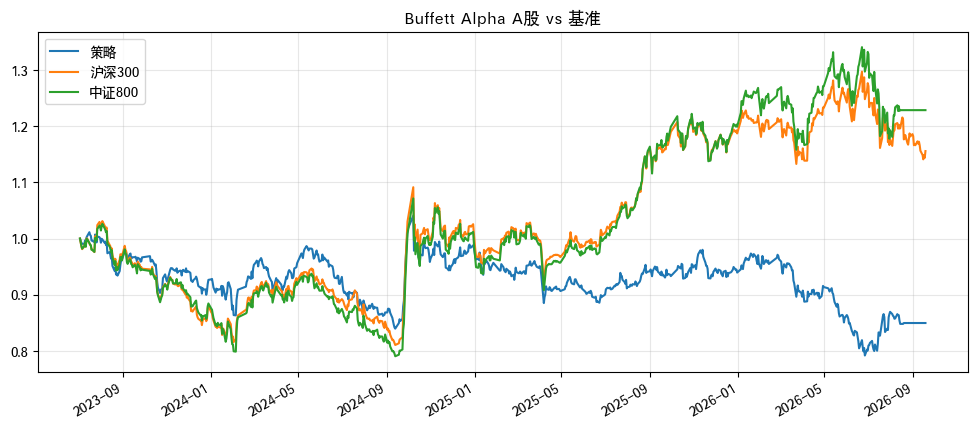

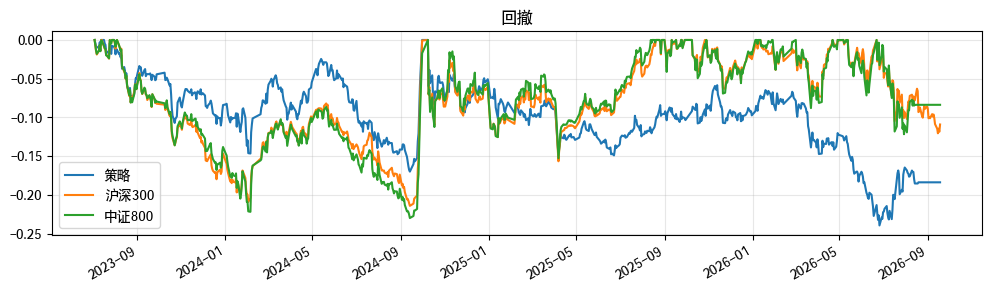

In [11]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Hei', 'Heiti TC', 'STHeiti', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1. 净值对比（等起点）+ 回撤
norm = cmp.div(cmp.iloc[0])
fig, ax = plt.subplots(figsize=(12, 5))
norm.plot(ax=ax); ax.set_title('Buffett Alpha A股 vs 基准'); ax.grid(True, alpha=.3)
plt.show()
(norm.div(norm.cummax()) - 1).plot(figsize=(12, 3), title='回撤'); plt.grid(True, alpha=.3); plt.show()

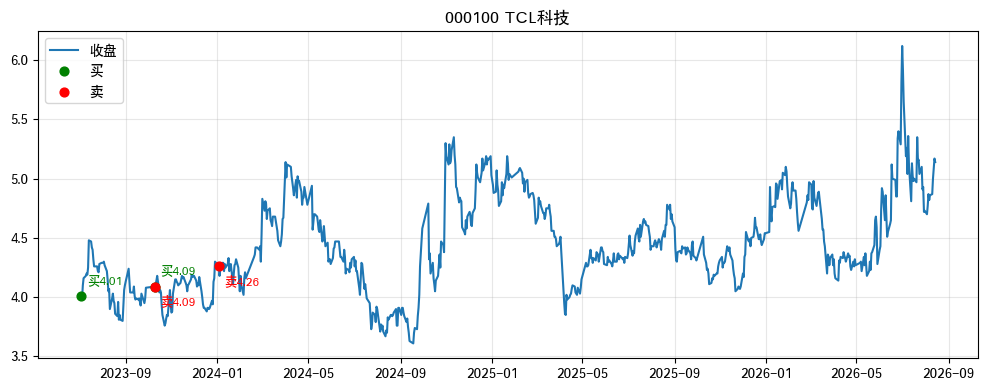

买入理由 2023-07-03 综合第1名 PE7.5 PB1.37 股息3.77% ROE18.1% Beta0.89 TTM增速41.2% 市值679亿
买入理由 2023-10-09 综合第16名 PE19.6 PB1.52 股息3.67% ROE7.8% Beta0.91 TTM增速-60.7% 市值768亿
买2023-07-04@4.01 卖2023-10-10@4.09 季度全卖 收益1.91%
买2023-10-10@4.09 卖2024-01-03@4.26 季度全卖 收益4.07%
合计: 投入48584 收回50025 总收益2.97%
---


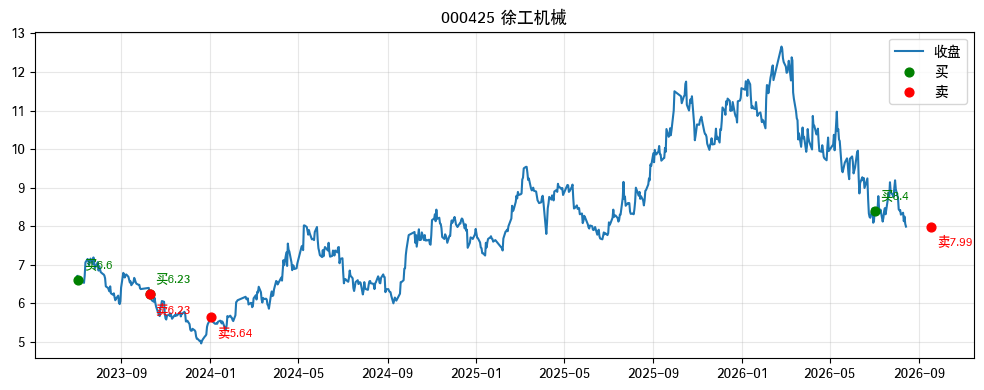

买入理由 2023-07-03 综合第20名 PE9.3 PB1.47 股息2.24% ROE15.8% Beta1.07 TTM增速76.5% 市值793亿
买入理由 2023-10-09 综合第9名 PE9.4 PB1.39 股息2.34% ROE14.9% Beta1.02 TTM增速47.5% 市值756亿
买入理由 2026-07-01 综合第19名 PE14.5 PB1.52 股息2.46% ROE10.5% Beta0.99 TTM增速1.8% 市值955亿
买2023-07-04@6.6 卖2023-10-10@6.23 季度全卖 收益-5.68%
买2023-10-10@6.23 卖2024-01-03@5.64 季度全卖 收益-9.54%
买2026-07-02@8.4 卖2026-09-18@7.99 期末持有 收益-2.98%
合计: 投入68254 收回64007 总收益-6.22%
---


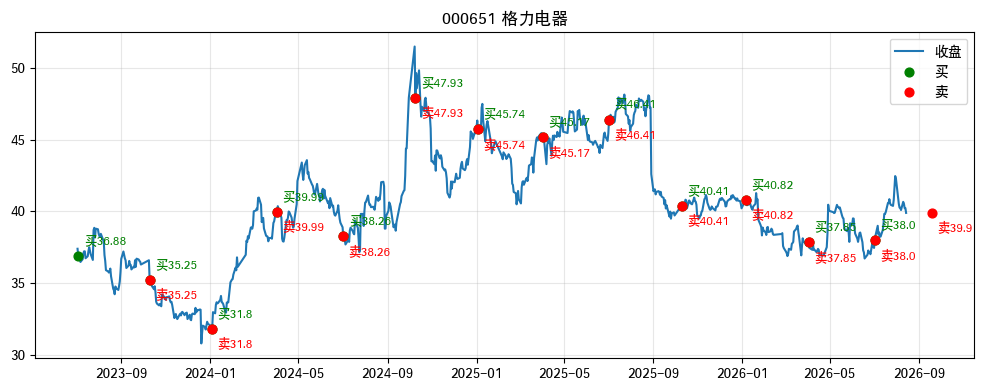

买入理由 2023-07-03 综合第12名 PE8.9 PB2.07 股息2.67% ROE23.2% Beta1.0 TTM增速-1.8% 市值2106亿
买入理由 2023-10-09 综合第6名 PE8.2 PB1.96 股息2.73% ROE23.8% Beta0.98 TTM增速-0.8% 市值2061亿
买入理由 2024-01-02 综合第4名 PE7.0 PB1.61 股息3.12% ROE22.9% Beta0.98 TTM增速6.6% 市值1804亿
买入理由 2024-04-01 综合第5名 PE8.8 PB2.01 股息2.49% ROE22.9% Beta0.79 TTM增速6.6% 市值2259亿
买入理由 2024-07-01 综合第7名 PE8.9 PB1.8 股息2.57% ROE20.2% Beta0.77 TTM增速4.2% 市值2191亿
买入理由 2024-10-08 综合第5名 PE11.3 PB2.46 股息4.62% ROE21.8% Beta0.81 TTM增速2.5% 市值2900亿
买入理由 2025-01-02 综合第2名 PE9.9 PB2.07 股息5.14% ROE20.8% Beta0.83 TTM增速2.2% 市值2610亿
买入理由 2025-04-01 综合第2名 PE9.7 PB2.01 股息5.27% ROE20.8% Beta0.85 TTM增速2.2% 市值2541亿
买入理由 2025-07-01 综合第4名 PE8.6 PB1.78 股息2.20% ROE20.7% Beta0.84 TTM增速20.2% 市值2546亿
买入理由 2025-10-09 综合第1名 PE7.7 PB1.67 股息4.95% ROE21.6% Beta0.81 TTM增速-3.9% 市值2262亿
买入理由 2026-01-05 综合第1名 PE8.0 PB1.58 股息4.91% ROE19.8% Beta0.64 TTM增速-7.7% 市值2283亿
买入理由 2026-04-01 综合第2名 PE7.5 PB1.47 股息5.26% ROE19.8% Beta0.66 TTM增速-7.7% 市值2130亿
买入理由 2026-07-01 综合第2名 PE7.2 PB1.38 股息5.34% ROE

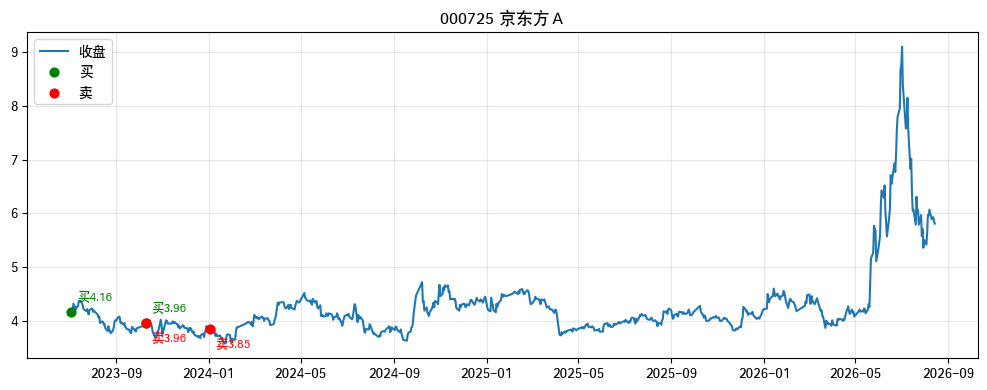

买入理由 2023-07-03 综合第6名 PE6.3 PB1.2 股息1.47% ROE19.0% Beta0.95 TTM增速157.9% 市值1589亿
买入理由 2023-10-09 综合第10名 PE7.6 PB1.16 股息1.56% ROE15.2% Beta0.94 TTM增速16.8% 市值1497亿
买2023-07-04@4.16 卖2023-10-10@3.96 季度全卖 收益-4.88%
买2023-10-10@3.96 卖2024-01-03@3.85 季度全卖 收益-2.86%
合计: 投入48720 收回46822 总收益-3.90%
---


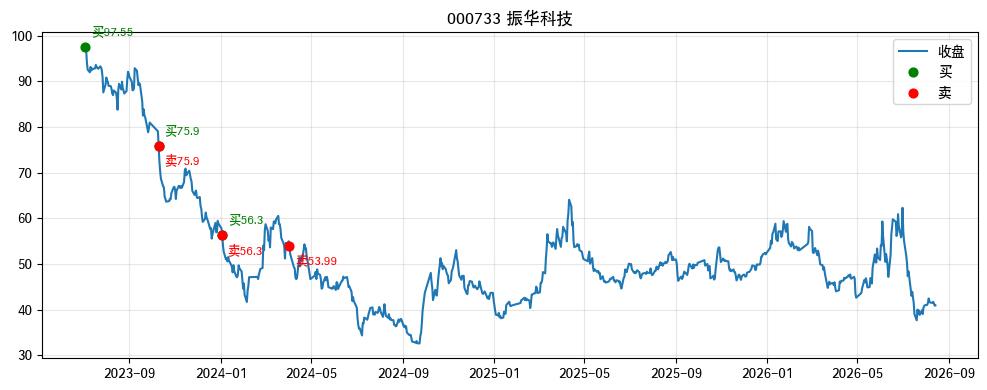

买入理由 2023-07-03 综合第13名 PE27.4 PB4.83 股息1.17% ROE17.6% Beta0.62 TTM增速149.7% 市值507亿
买入理由 2023-10-09 综合第4名 PE18.3 PB3.85 股息1.45% ROE21.0% Beta0.58 TTM增速154.0% 市值411亿
买入理由 2024-01-02 综合第3名 PE13.3 PB2.32 股息1.98% ROE17.5% Beta0.76 TTM增速99.5% 市值319亿
买2023-07-04@97.55 卖2023-10-10@75.9 季度全卖 收益-22.26%
买2023-10-10@75.9 卖2024-01-03@56.3 季度全卖 收益-25.88%
买2024-01-03@56.3 卖2024-04-02@53.99 季度全卖 收益-4.18%
合计: 投入64800 收回53622 总收益-17.25%
---


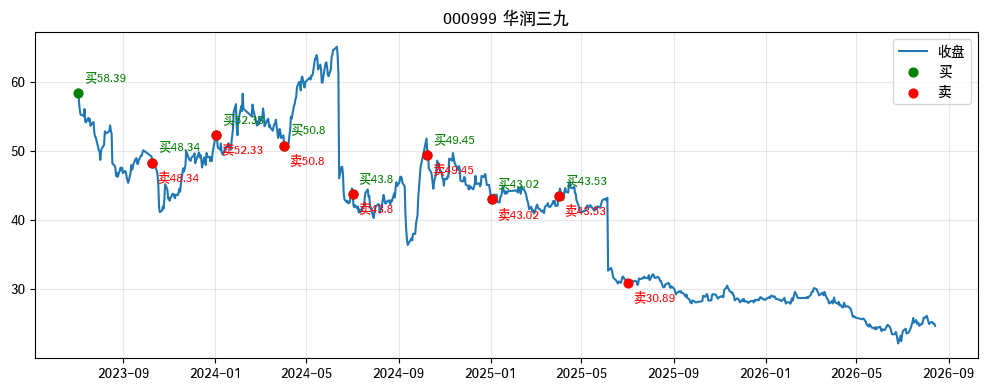

买入理由 2023-07-03 综合第10名 PE25.8 PB3.2 股息1.70% ROE12.4% Beta0.5 TTM增速31.2% 市值582亿
买入理由 2023-10-09 综合第8名 PE23.0 PB2.71 股息2.03% ROE11.8% Beta0.52 TTM增速10.1% 市值486亿
买入理由 2024-01-02 综合第11名 PE22.9 PB2.79 股息1.92% ROE12.2% Beta0.57 TTM增速27.0% 市值516亿
买入理由 2024-04-01 综合第14名 PE21.1 PB2.79 股息1.91% ROE13.2% Beta0.61 TTM增速19.2% 市值517亿
买入理由 2024-07-01 综合第6名 PE16.0 PB2.17 股息3.36% ROE13.6% Beta0.63 TTM增速22.5% 市值441亿
买入理由 2024-10-08 综合第12名 PE23.0 PB3.34 股息2.89% ROE14.5% Beta0.88 TTM增速37.0% 市值666亿
买入理由 2025-01-02 综合第10名 PE19.1 PB2.7 股息3.48% ROE14.1% Beta0.86 TTM增速28.8% 市值554亿
买入理由 2025-04-01 综合第18名 PE19.6 PB2.72 股息3.45% ROE13.9% Beta0.87 TTM增速16.5% 市值558亿
买2023-07-04@58.39 卖2023-10-10@48.34 季度全卖 收益-17.28%
买2023-10-10@48.34 卖2024-01-03@52.33 季度全卖 收益8.17%
买2024-01-03@52.33 卖2024-04-02@50.8 季度全卖 收益-3.00%
买2024-04-02@50.8 卖2024-07-02@43.8 季度全卖 收益14.65%
买2024-07-02@43.8 卖2024-10-09@49.45 季度全卖 收益12.81%
买2024-10-09@49.45 卖2025-01-03@43.02 季度全卖 收益-11.25%
买2025-01-03@43.02 卖2025-04-02@43.53 季度全卖 收益1.10%
买2025-04-02

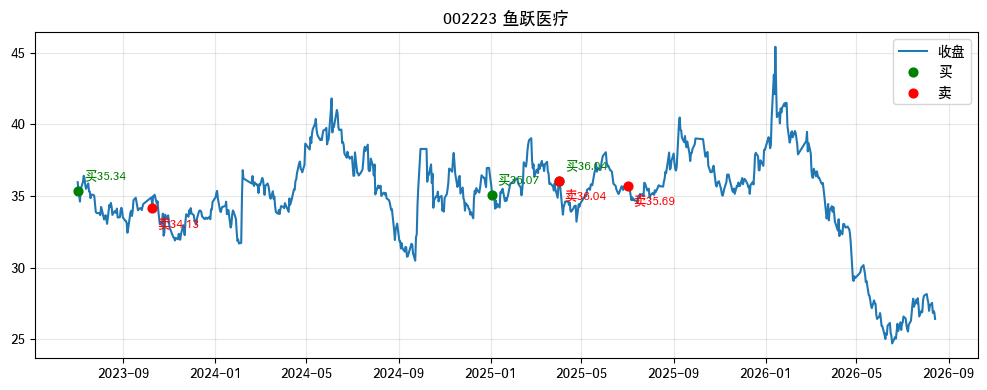

买入理由 2023-07-03 综合第15名 PE24.2 PB3.41 股息1.67% ROE14.1% Beta0.67 TTM增速-19.0% 市值360亿
买入理由 2025-01-02 综合第16名 PE13.5 PB2.85 股息1.12% ROE21.1% Beta0.88 TTM增速109.3% 市值358亿
买入理由 2025-04-01 综合第7名 PE13.5 PB2.85 股息1.12% ROE21.1% Beta0.85 TTM增速109.3% 市值358亿
买2023-07-04@35.34 卖2023-10-10@34.13 季度全卖 收益-3.50%
买2025-01-03@35.07 卖2025-04-02@36.04 季度全卖 收益2.68%
买2025-04-02@36.04 卖2025-07-02@35.69 季度全卖 收益-0.05%
合计: 投入67404 收回67090 总收益-0.47%
---


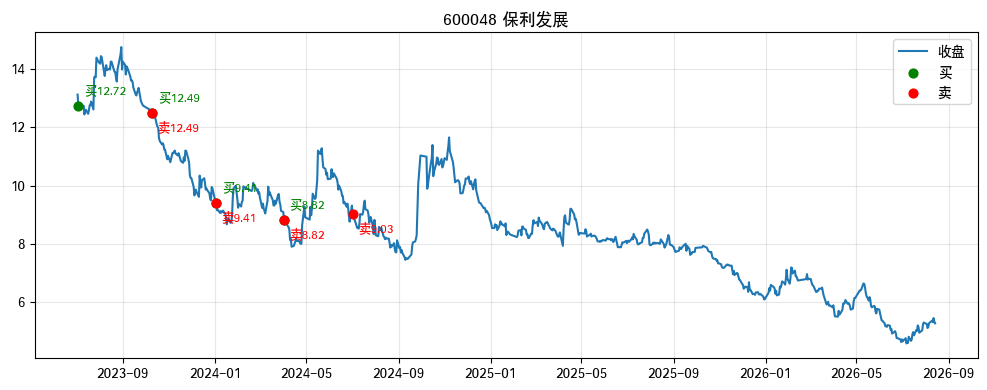

买入理由 2023-07-03 综合第18名 PE5.7 PB0.79 股息3.43% ROE13.8% Beta1.03 TTM增速-5.7% 市值1571亿
买入理由 2023-10-09 综合第18名 PE5.4 PB0.75 股息3.58% ROE14.0% Beta1.05 TTM增速-4.1% 市值1505亿
买入理由 2024-01-02 综合第8名 PE4.2 PB0.56 股息4.77% ROE13.4% Beta0.99 TTM增速-8.2% 市值1129亿
买入理由 2024-04-01 综合第16名 PE4.0 PB0.54 股息4.95% ROE13.4% Beta1.02 TTM增速-8.2% 市值1088亿
买2023-07-04@12.72 卖2023-10-10@12.49 季度全卖 收益-1.89%
买2023-10-10@12.49 卖2024-01-03@9.41 季度全卖 收益-24.72%
买2024-01-03@9.41 卖2024-04-02@8.82 季度全卖 收益-6.35%
买2024-04-02@8.82 卖2024-07-02@9.03 季度全卖 收益2.30%
合计: 投入93415 收回86187 总收益-7.74%
---


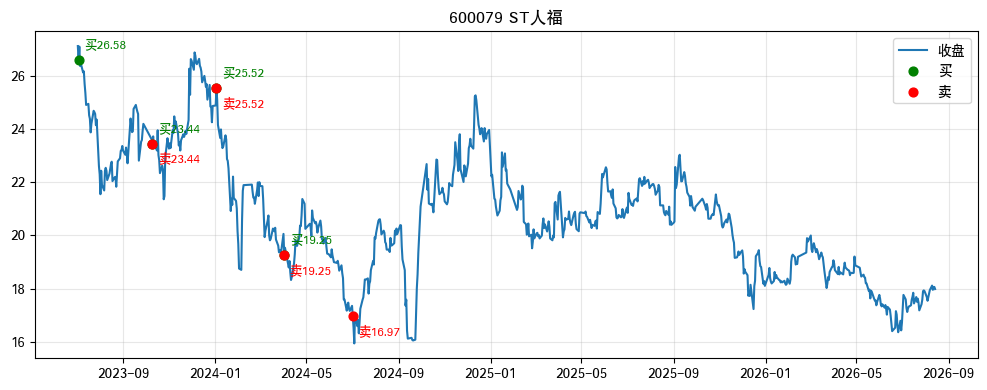

买入理由 2023-07-03 综合第16名 PE22.9 PB2.81 股息0.59% ROE12.3% Beta0.6 TTM增速47.1% 市值443亿
买入理由 2023-10-09 综合第11名 PE17.9 PB2.38 股息0.68% ROE13.3% Beta0.55 TTM增速52.1% 市值385亿
买入理由 2024-01-02 综合第12名 PE16.6 PB2.43 股息0.64% ROE14.6% Beta0.57 TTM增速50.2% 市值406亿
买入理由 2024-04-01 综合第17名 PE13.2 PB1.96 股息0.80% ROE14.8% Beta0.81 TTM增速88.6% 市值328亿
买2023-07-04@26.58 卖2023-10-10@23.44 季度全卖 收益-11.88%
买2023-10-10@23.44 卖2024-01-03@25.52 季度全卖 收益8.79%
买2024-01-03@25.52 卖2024-04-02@19.25 季度全卖 收益-24.63%
买2024-04-02@19.25 卖2024-07-02@16.97 季度全卖 收益-9.77%
合计: 投入91505 收回82996 总收益-9.30%
---


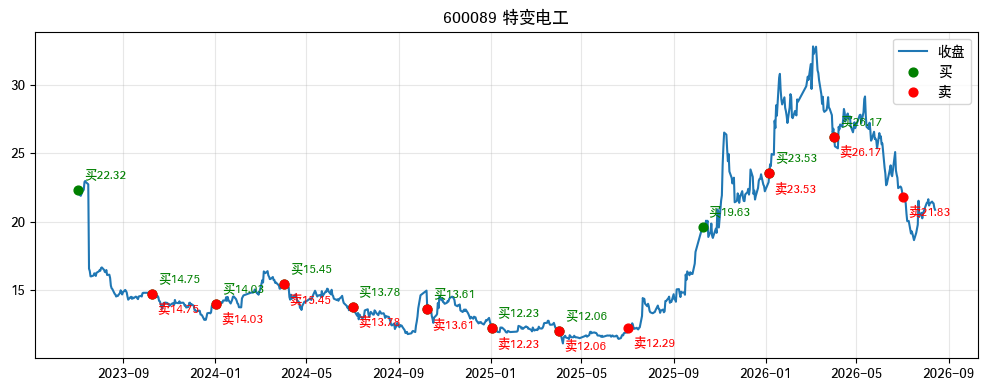

买入理由 2023-07-03 综合第7名 PE10.6 PB1.41 股息2.58% ROE13.4% Beta0.93 TTM增速98.7% 市值875亿
买入理由 2023-10-09 综合第1名 PE5.2 PB0.95 股息7.56% ROE18.3% Beta0.95 TTM增速138.5% 市值577亿
买入理由 2024-01-02 综合第2名 PE5.3 PB1.14 股息8.07% ROE21.3% Beta0.99 TTM增速116.0% 市值701亿
买入理由 2024-04-01 综合第3名 PE6.0 PB1.27 股息7.20% ROE21.3% Beta1.0 TTM增速116.0% 市值786亿
买入理由 2024-07-01 综合第11名 PE4.0 PB1.07 股息1.43% ROE26.5% Beta1.01 TTM增速112.3% 市值705亿
买入理由 2024-10-08 综合第9名 PE4.6 PB1.15 股息1.34% ROE25.1% Beta0.96 TTM增速49.3% 市值757亿
买入理由 2025-01-02 综合第18名 PE4.4 PB0.91 股息1.62% ROE20.7% Beta0.97 TTM增速8.1% 市值625亿
买入理由 2025-04-01 综合第19名 PE4.3 PB0.89 股息1.66% ROE20.7% Beta0.97 TTM增速8.1% 市值608亿
买入理由 2025-10-09 综合第7名 PE9.1 PB1.38 股息1.28% ROE15.1% Beta0.99 TTM增速73.7% 市值989亿
买入理由 2026-01-05 综合第20名 PE9.7 PB1.56 股息1.09% ROE16.0% Beta1.23 TTM增速111.3% 市值1156亿
买入理由 2026-04-01 综合第20名 PE11.4 PB1.82 股息0.93% ROE16.0% Beta1.21 TTM增速111.3% 市值1353亿
买2023-07-04@22.32 卖2023-10-10@14.75 季度全卖 收益-10.15%
买2023-10-10@14.75 卖2024-01-03@14.03 季度全卖 收益-4.96%
买2024-01-03@14.03 

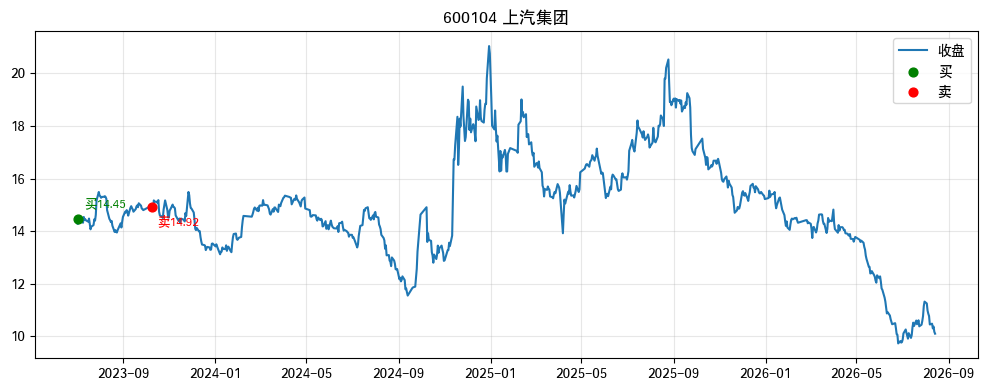

买入理由 2023-07-03 综合第9名 PE7.2 PB0.59 股息4.78% ROE8.2% Beta0.82 TTM增速-11.3% 市值1668亿
买2023-07-04@14.45 卖2023-10-10@14.92 季度全卖 收益5.03%
合计: 投入24565 收回25802 总收益5.04%
---


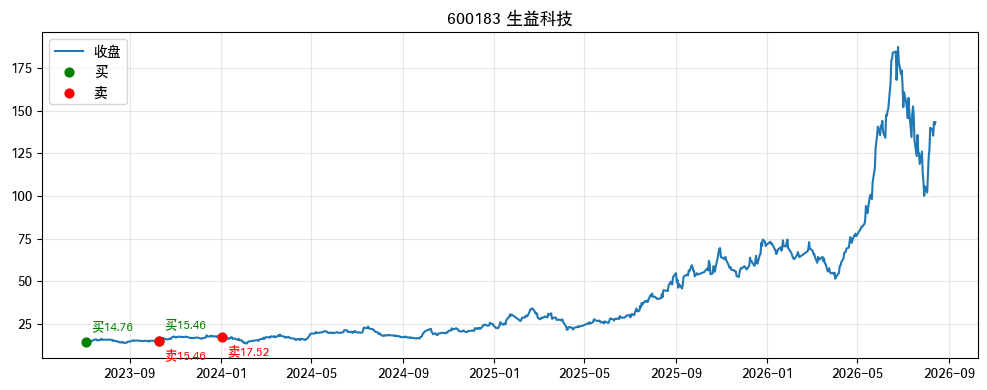

买入理由 2023-07-03 综合第8名 PE12.1 PB2.42 股息3.13% ROE19.9% Beta0.96 TTM增速46.8% 市值336亿
买入理由 2023-10-09 综合第13名 PE15.3 PB2.7 股息2.94% ROE17.7% Beta0.98 TTM增速3.6% 市值360亿
买2023-07-04@14.76 卖2023-10-10@15.46 季度全卖 收益4.66%
买2023-10-10@15.46 卖2024-01-03@17.52 季度全卖 收益13.23%
合计: 投入46806 收回50975 总收益8.91%
---


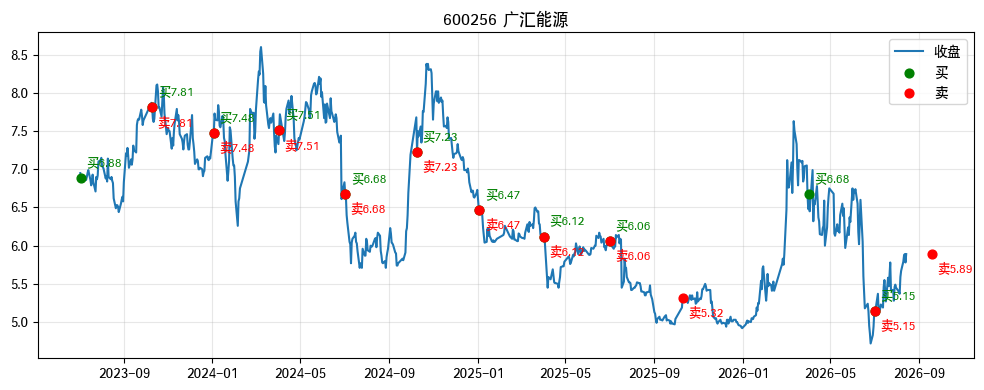

买入理由 2023-07-03 综合第3名 PE7.1 PB1.43 股息11.51% ROE20.1% Beta1.04 TTM增速241.2% 市值456亿
买入理由 2023-10-09 综合第2名 PE5.9 PB1.84 股息10.17% ROE31.1% Beta1.02 TTM增速315.9% 市值517亿
买入理由 2024-01-02 综合第1名 PE4.6 PB1.7 股息10.70% ROE37.0% Beta0.89 TTM增速214.2% 市值491亿
买入理由 2024-04-01 综合第2名 PE4.5 PB1.67 股息10.91% ROE37.0% Beta0.95 TTM增速214.2% 市值481亿
买入理由 2024-07-01 综合第1名 PE3.7 PB1.51 股息10.25% ROE40.7% Beta0.92 TTM增速89.1% 市值448亿
买入理由 2024-10-08 综合第3名 PE4.9 PB1.95 股息9.11% ROE39.9% Beta0.91 TTM增速18.4% 市值504亿
买入理由 2025-01-02 综合第3名 PE5.5 PB1.62 股息10.79% ROE29.5% Beta0.91 TTM增速-26.9% 市值426亿
买入理由 2025-04-01 综合第1名 PE5.2 PB1.53 股息11.42% ROE29.5% Beta0.84 TTM增速-26.9% 市值402亿
买入理由 2025-07-01 综合第12名 PE13.4 PB1.43 股息11.63% ROE10.7% Beta0.9 TTM增速-75.6% 市值395亿
买入理由 2026-04-01 综合第1名 PE9.9 PB1.74 股息9.60% ROE17.6% Beta0.67 TTM增速82.5% 市值414亿
买入理由 2026-07-01 综合第8名 PE36.9 PB1.34 股息12.12% ROE3.6% Beta0.35 TTM增速-68.7% 市值328亿
买2023-07-04@6.88 卖2023-10-10@7.81 季度全卖 收益13.43%
买2023-10-10@7.81 卖2024-01-03@7.48 季度全卖 收益-4.30%
买2024-01-03@7.48 卖

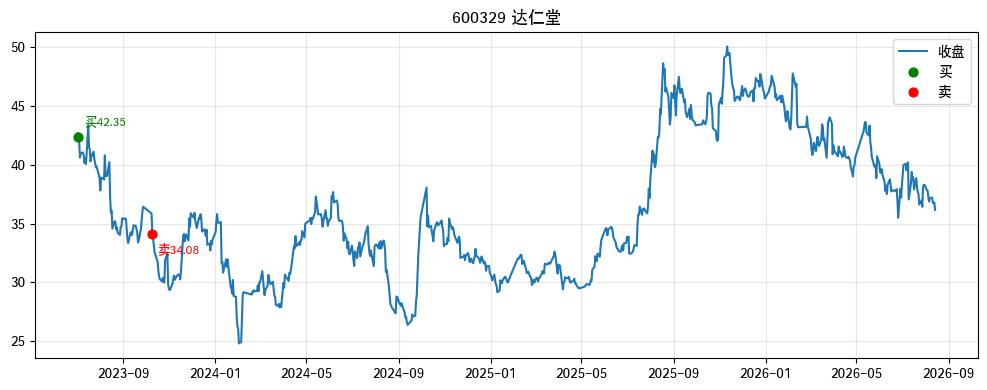

买入理由 2023-07-03 综合第17名 PE43.7 PB4.78 股息2.62% ROE10.9% Beta0.5 TTM增速7.2% 市值330亿
买2023-07-04@42.35 卖2023-10-10@34.08 季度全卖 收益-19.59%
合计: 投入21175 收回17026 总收益-19.59%
---


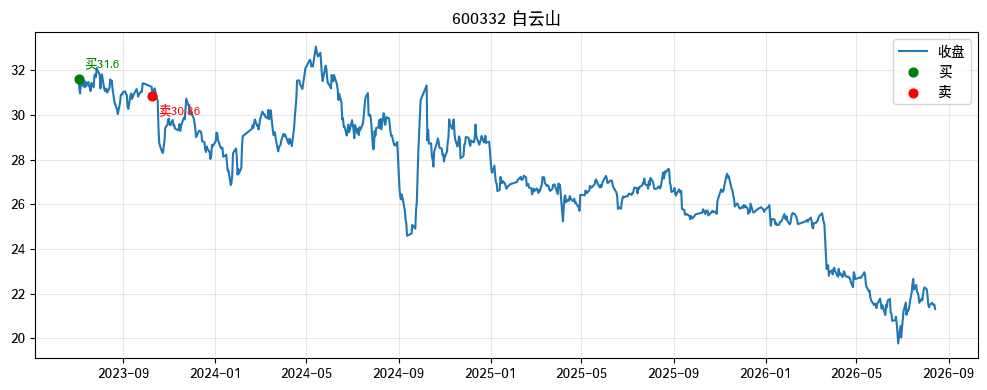

买入理由 2023-07-03 综合第5名 PE13.2 PB1.51 股息2.31% ROE11.5% Beta0.66 TTM增速16.1% 市值514亿
买2023-07-04@31.6 卖2023-10-10@30.86 季度全卖 收益-2.42%
合计: 投入22120 收回21585 总收益-2.42%
---


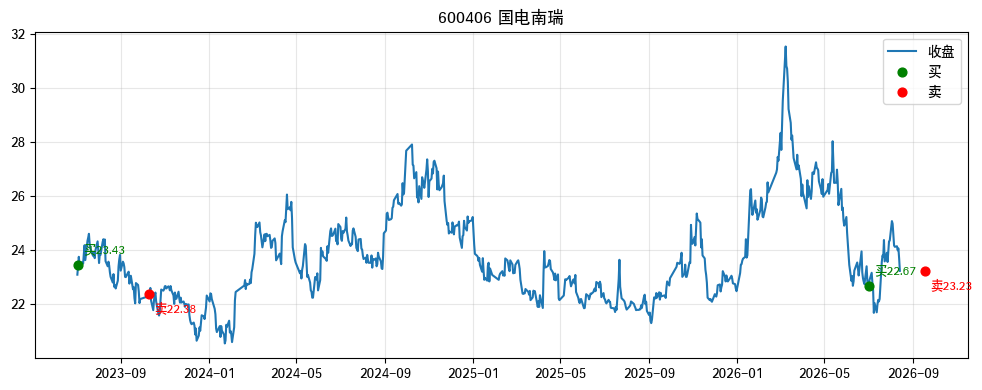

买入理由 2023-07-03 综合第19名 PE26.6 PB3.59 股息1.69% ROE13.5% Beta0.83 TTM增速16.9% 市值1546亿
买入理由 2026-07-01 综合第17名 PE21.9 PB3.4 股息2.10% ROE15.6% Beta0.83 TTM增速8.1% 市值1821亿
买2023-07-04@23.43 卖2023-10-10@22.38 季度全卖 收益-4.56%
买2026-07-02@22.67 卖2026-09-18@23.23 期末持有 收益2.47%
合计: 投入41566 收回40946 总收益-1.49%
---


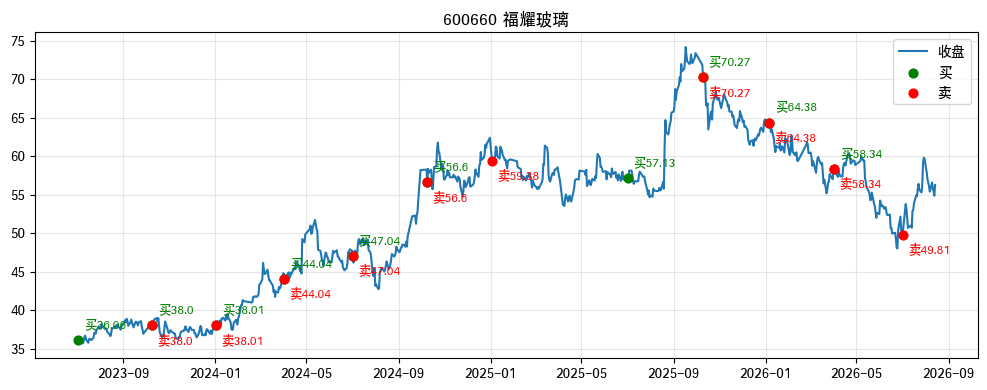

买入理由 2023-07-03 综合第14名 PE29.4 PB3.12 股息3.51% ROE10.6% Beta0.83 TTM增速5.5% 市值931亿
买入理由 2023-10-09 综合第14名 PE26.6 PB3.47 股息3.26% ROE13.1% Beta0.79 TTM增速10.4% 市值1000亿
买入理由 2024-01-02 综合第10名 PE22.1 PB3.27 股息3.32% ROE14.8% Beta0.74 TTM增速28.1% 市值983亿
买入理由 2024-04-01 综合第8名 PE24.6 PB3.89 股息2.79% ROE15.8% Beta0.71 TTM增速51.2% 市值1169亿
买入理由 2024-07-01 综合第10名 PE26.0 PB3.79 股息2.72% ROE14.6% Beta0.7 TTM增速51.8% 市值1246亿
买入理由 2024-10-08 综合第15名 PE29.2 PB4.81 股息2.23% ROE16.5% Beta0.68 TTM增速38.6% 市值1521亿
买入理由 2025-07-01 综合第11名 PE24.3 PB3.93 股息3.17% ROE16.2% Beta0.71 TTM增速27.2% 市值1484亿
买入理由 2025-10-09 综合第16名 PE27.0 PB5.26 股息1.25% ROE19.4% Beta0.72 TTM增速10.2% 市值1876亿
买入理由 2026-01-05 综合第16名 PE23.3 PB4.75 股息1.40% ROE20.3% Beta0.81 TTM增速3.3% 市值1683亿
买入理由 2026-04-01 综合第6名 PE16.2 PB4.26 股息1.55% ROE26.2% Beta0.84 TTM增速24.2% 市值1513亿
买2023-07-04@36.06 卖2023-10-10@38.0 季度全卖 收益5.29%
买2023-10-10@38.0 卖2024-01-03@38.01 季度全卖 收益-0.05%
买2024-01-03@38.01 卖2024-04-02@44.04 季度全卖 收益15.77%
买2024-04-02@44.04 卖2024-07-02@47.04 季度全卖

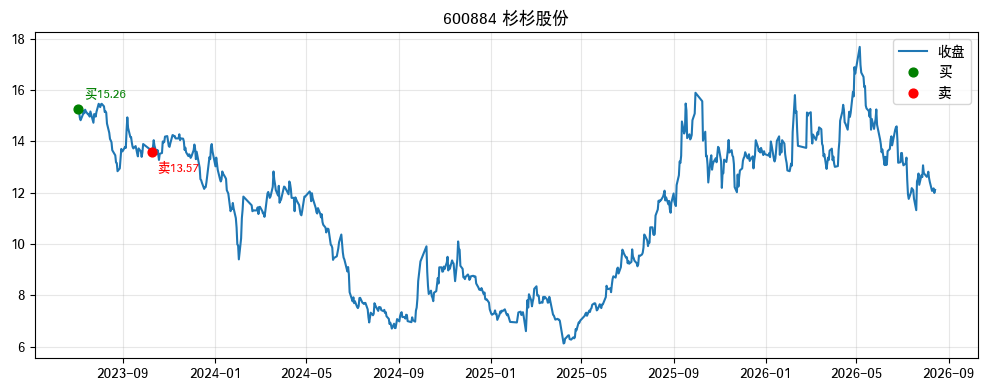

买入理由 2023-07-03 综合第2名 PE8.9 PB1.46 股息1.98% ROE16.3% Beta0.94 TTM增速633.6% 市值343亿
买2023-07-04@15.26 卖2023-10-10@13.57 季度全卖 收益-11.15%
合计: 投入24416 收回21694 总收益-11.15%
---


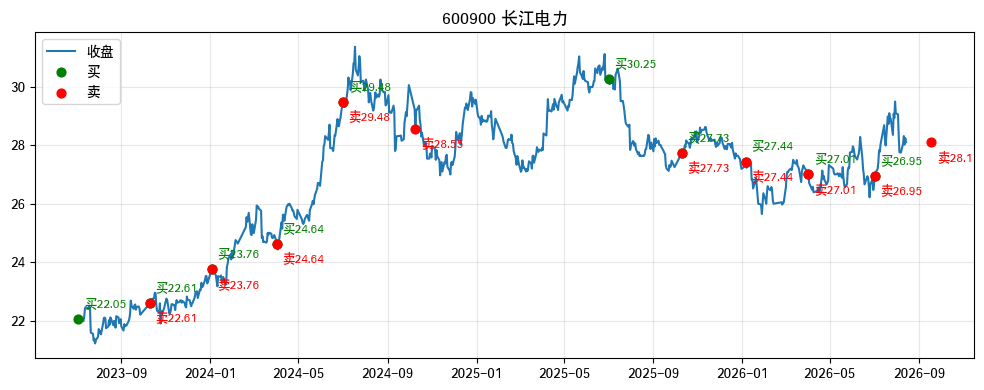

买入理由 2023-07-03 综合第4名 PE19.7 PB2.83 股息3.69% ROE14.3% Beta0.63 TTM增速-1.4% 市值5234亿
买入理由 2023-10-09 综合第3名 PE18.9 PB2.98 股息3.78% ROE15.8% Beta0.57 TTM增速8.2% 市值5520亿
买入理由 2024-01-02 综合第5名 PE21.2 PB2.94 股息3.60% ROE13.9% Beta0.5 TTM增速6.9% 市值5794亿
买入理由 2024-04-01 综合第10名 PE22.1 PB3.07 股息3.45% ROE13.9% Beta0.46 TTM增速6.9% 市值6051亿
买入理由 2024-07-01 综合第20名 PE29.8 PB3.51 股息2.89% ROE11.8% Beta0.41 TTM增速-8.6% 市值7213亿
买入理由 2025-07-01 综合第19名 PE26.9 PB3.44 股息2.70% ROE12.8% Beta0.49 TTM增速13.9% 市值7431亿
买入理由 2025-10-09 综合第11名 PE23.4 PB3.28 股息2.65% ROE14.0% Beta0.5 TTM增速-2.7% 市值6773亿
买入理由 2026-01-05 综合第6名 PE24.3 PB3.02 股息2.69% ROE12.4% Beta0.43 TTM增速-18.8% 市值6675亿
买入理由 2026-04-01 综合第11名 PE24.0 PB2.97 股息2.73% ROE12.4% Beta0.45 TTM增速-18.8% 市值6577亿
买入理由 2026-07-01 综合第6名 PE18.1 PB2.86 股息2.75% ROE15.8% Beta0.42 TTM增速7.0% 市值6518亿
买2023-07-04@22.05 卖2023-10-10@22.61 季度全卖 收益5.55%
买2023-10-10@22.61 卖2024-01-03@23.76 季度全卖 收益5.00%
买2024-01-03@23.76 卖2024-04-02@24.64 季度全卖 收益3.62%
买2024-04-02@24.64 卖2024-07-02@29.48 季度全卖 收

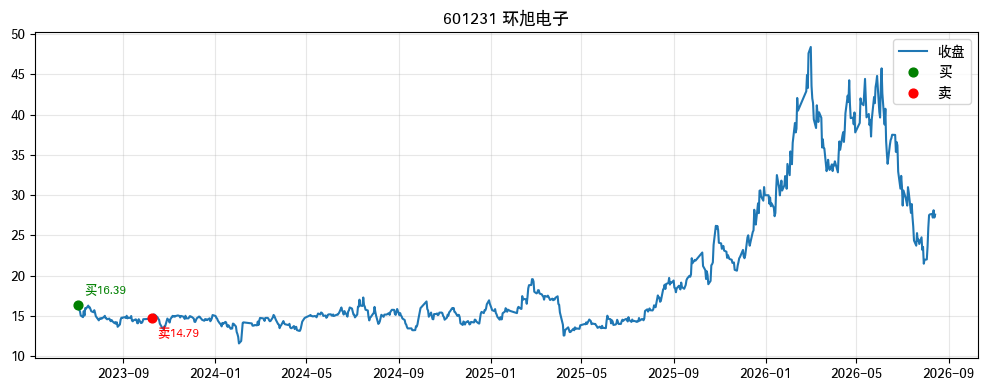

买入理由 2023-07-03 综合第11名 PE17.7 PB2.27 股息2.61% ROE12.8% Beta0.79 TTM增速14.5% 市值363亿
买2023-07-04@16.39 卖2023-10-10@14.79 季度全卖 收益-9.84%
合计: 投入24585 收回22167 总收益-9.84%
---


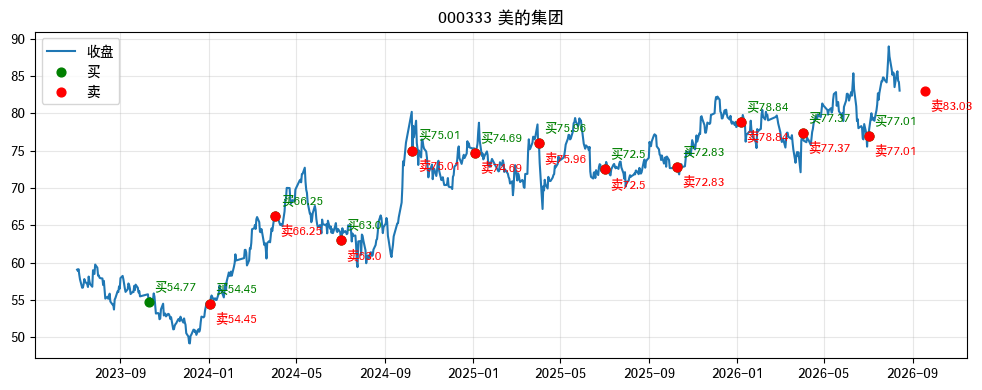

买入理由 2023-10-09 综合第17名 PE13.2 PB2.68 股息4.48% ROE20.2% Beta1.09 TTM增速4.4% 市值3916亿
买入理由 2024-01-02 综合第7名 PE13.0 PB2.46 股息4.58% ROE18.9% Beta0.99 TTM增速3.2% 市值3836亿
买入理由 2024-04-01 综合第7名 PE15.8 PB2.98 股息3.78% ROE18.9% Beta0.79 TTM增速3.4% 市值4656亿
买入理由 2024-07-01 综合第4名 PE14.7 PB2.59 股息4.68% ROE17.6% Beta0.71 TTM增速3.9% 市值4467亿
买入理由 2024-10-08 综合第7名 PE17.6 PB3.4 股息3.74% ROE19.3% Beta0.72 TTM增速7.5% 市值5597亿
买入理由 2025-01-02 综合第6名 PE17.6 PB2.76 股息3.98% ROE15.7% Beta0.75 TTM增速10.9% 市值5761亿
买入理由 2025-04-01 综合第4名 PE17.1 PB2.76 股息3.98% ROE16.1% Beta0.77 TTM增速14.1% 市值5767亿
买入理由 2025-07-01 综合第7名 PE15.9 PB2.4 股息4.85% ROE15.1% Beta0.84 TTM增速14.0% 市值5524亿
买入理由 2025-10-09 综合第2名 PE14.3 PB2.58 股息4.82% ROE18.0% Beta0.8 TTM增速7.3% 市值5568亿
买入理由 2026-01-05 综合第5名 PE15.1 PB2.74 股息0.64% ROE18.1% Beta0.72 TTM增速5.8% 市值6045亿
买入理由 2026-04-01 综合第8名 PE13.4 PB2.68 股息0.65% ROE19.9% Beta0.72 TTM增速14.0% 市值5904亿
买入理由 2026-07-01 综合第3名 PE13.3 PB2.53 股息4.91% ROE19.0% Beta0.43 TTM增速5.3% 市值5885亿
买2023-10-10@54.77 卖2024-01-03@54.45 季度

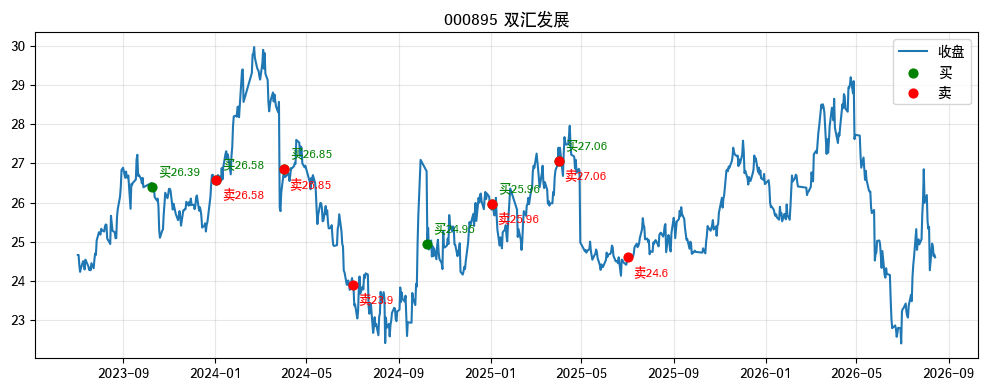

买入理由 2023-10-09 综合第7名 PE18.1 PB4.33 股息2.83% ROE23.8% Beta0.73 TTM增速-12.0% 市值918亿
买入理由 2024-01-02 综合第6名 PE16.8 PB4.57 股息2.82% ROE27.2% Beta0.7 TTM增速14.9% 市值920亿
买入理由 2024-04-01 综合第6名 PE16.5 PB4.6 股息2.81% ROE27.9% Beta0.67 TTM增速15.5% 市值926亿
买入理由 2024-10-08 综合第8名 PE16.2 PB4.48 股息2.46% ROE27.7% Beta0.7 TTM增速13.2% 市值929亿
买入理由 2025-01-02 综合第11名 PE15.2 PB4.49 股息2.56% ROE29.5% Beta0.74 TTM增速7.4% 市值895亿
买入理由 2025-04-01 综合第17名 PE18.8 PB4.76 股息2.41% ROE25.4% Beta0.74 TTM增速-10.1% 市值949亿
买2023-10-10@26.39 卖2024-01-03@26.58 季度全卖 收益0.64%
买2024-01-03@26.58 卖2024-04-02@26.85 季度全卖 收益0.93%
买2024-04-02@26.85 卖2024-07-02@23.9 季度全卖 收益-8.98%
买2024-10-09@24.95 卖2025-01-03@25.96 季度全卖 收益3.96%
买2025-01-03@25.96 卖2025-04-02@27.06 季度全卖 收益4.15%
买2025-04-02@27.06 卖2025-07-02@24.6 季度全卖 收益-6.95%
合计: 投入133962 收回132741 总收益-0.91%
---


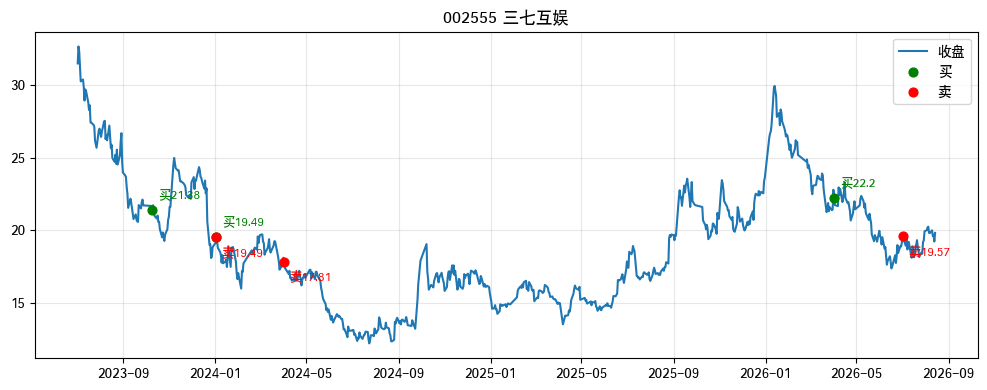

买入理由 2023-10-09 综合第15名 PE12.9 PB3.83 股息2.08% ROE29.6% Beta1.03 TTM增速94.1% 市值480亿
买入理由 2024-01-02 综合第14名 PE12.4 PB3.44 股息2.35% ROE27.6% Beta1.06 TTM增速53.5% 市值424亿
买入理由 2026-04-01 综合第17名 PE16.2 PB3.74 股息0.92% ROE23.1% Beta1.11 TTM增速31.4% 市值504亿
买2023-10-10@21.38 卖2024-01-03@19.49 季度全卖 收益-8.91%
买2024-01-03@19.49 卖2024-04-02@17.81 季度全卖 收益-8.69%
买2026-04-02@22.2 卖2026-07-02@19.57 季度全卖 收益-9.45%
合计: 投入67157 收回61100 总收益-9.02%
---


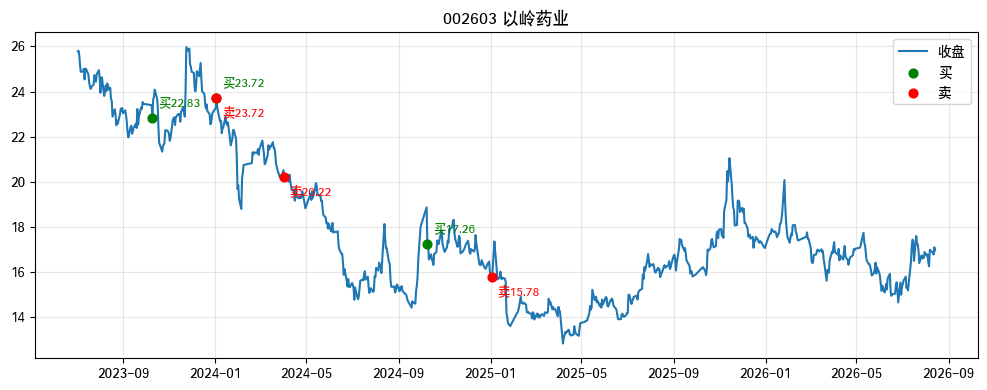

买入理由 2023-10-09 综合第19名 PE27.4 PB3.34 股息2.14% ROE12.2% Beta0.58 TTM增速-2.7% 市值391亿
买入理由 2024-01-02 综合第15名 PE25.3 PB3.28 股息2.15% ROE12.9% Beta0.7 TTM增速7.6% 市值389亿
买入理由 2024-10-08 综合第14名 PE10.8 PB2.75 股息1.59% ROE25.4% Beta1.0 TTM增速104.5% 市值315亿
买2023-10-10@22.83 卖2024-01-03@23.72 季度全卖 收益3.81%
买2024-01-03@23.72 卖2024-04-02@20.22 季度全卖 收益-14.82%
买2024-10-09@17.26 卖2025-01-03@15.78 季度全卖 收益-8.65%
合计: 投入68342 收回63958 总收益-6.41%
---


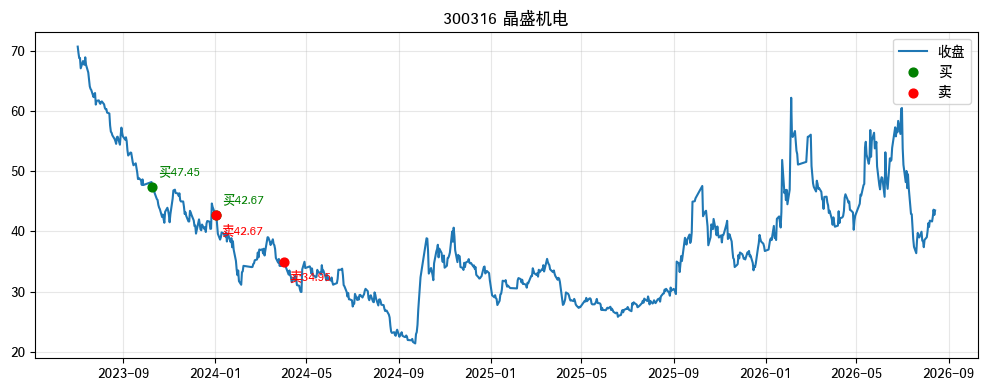

买入理由 2023-10-09 综合第20名 PE27.2 PB5.01 股息0.93% ROE18.4% Beta0.73 TTM增速96.1% 市值631亿
买入理由 2024-01-02 综合第16名 PE21.4 PB4.03 股息1.05% ROE18.8% Beta0.93 TTM增速80.7% 市值559亿
买2023-10-10@47.45 卖2024-01-03@42.67 季度全卖 收益-10.15%
买2024-01-03@42.67 卖2024-04-02@34.95 季度全卖 收益-18.16%
合计: 投入45060 收回38779 总收益-13.94%
---


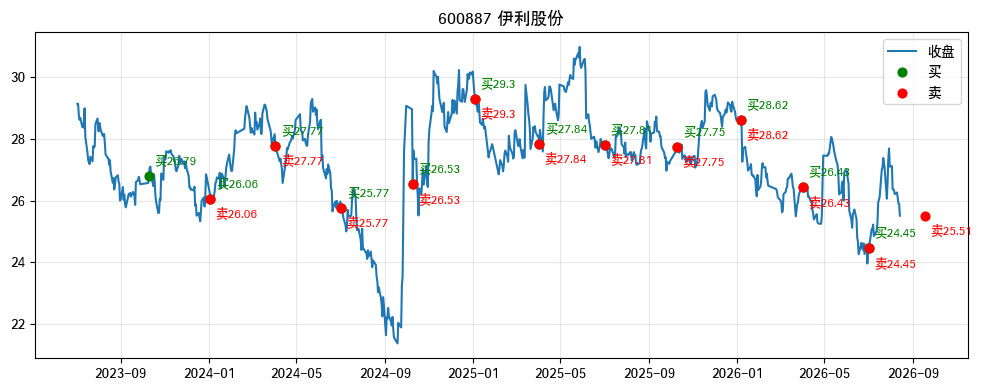

买入理由 2023-10-09 综合第12名 PE17.8 PB3.42 股息3.91% ROE19.2% Beta0.98 TTM增速9.8% 市值1692亿
买入理由 2024-01-02 综合第13名 PE19.0 PB3.21 股息3.96% ROE16.9% Beta0.95 TTM增速-2.0% 市值1672亿
买入理由 2024-04-01 综合第15名 PE20.3 PB3.44 股息3.69% ROE16.9% Beta0.85 TTM增速-2.0% 市值1792亿
买入理由 2024-07-01 综合第9名 PE17.4 PB2.8 股息4.62% ROE16.1% Beta0.82 TTM增速1.4% 市值1653亿
买入理由 2024-10-08 综合第16名 PE19.2 PB3.48 股息4.14% ROE18.1% Beta0.9 TTM增速0.9% 市值1844亿
买入理由 2025-01-02 综合第9名 PE17.5 PB3.35 股息4.06% ROE19.1% Beta0.94 TTM增速21.9% 市值1882亿
买入理由 2025-04-01 综合第9名 PE16.6 PB3.18 股息4.28% ROE19.1% Beta0.97 TTM增速21.9% 市值1787亿
买入理由 2025-07-01 综合第5名 PE13.8 PB3.02 股息4.41% ROE21.8% Beta0.93 TTM增速33.7% 市值1761亿
买入理由 2025-10-09 综合第5名 PE17.3 PB3.28 股息4.42% ROE18.9% Beta0.88 TTM增速-13.4% 市值1748亿
买入理由 2026-01-05 综合第3名 PE18.1 PB3.21 股息4.26% ROE17.7% Beta0.68 TTM增速-16.2% 市值1810亿
买入理由 2026-04-01 综合第4名 PE16.7 PB2.96 股息4.63% ROE17.7% Beta0.67 TTM增速-16.2% 市值1665亿
买入理由 2026-07-01 综合第1名 PE12.7 PB2.58 股息3.70% ROE20.3% Beta0.57 TTM增速63.2% 市值1538亿
买2023-10-10@26.79 卖2024-01

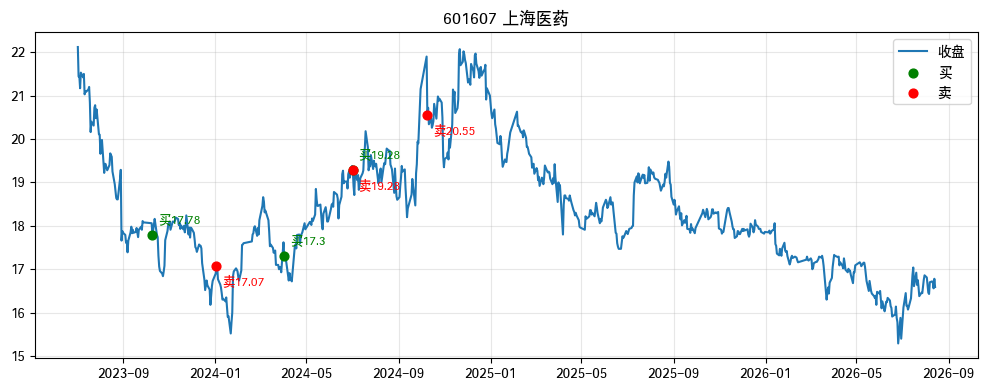

买入理由 2023-10-09 综合第5名 PE12.8 PB0.99 股息3.38% ROE7.8% Beta0.63 TTM增速-7.1% 市值669亿
买入理由 2024-04-01 综合第11名 PE11.6 PB0.95 股息3.46% ROE8.2% Beta0.73 TTM增速10.3% 市值653亿
买入理由 2024-07-01 综合第8名 PE12.2 PB1.02 股息3.15% ROE8.4% Beta0.8 TTM增速39.3% 市值718亿
买2023-10-10@17.78 卖2024-01-03@17.07 季度全卖 收益-4.07%
买2024-04-02@17.3 卖2024-07-02@19.28 季度全卖 收益11.35%
买2024-07-02@19.28 卖2024-10-09@20.55 季度全卖 收益8.57%
合计: 投入66812 收回70243 总收益5.14%
---


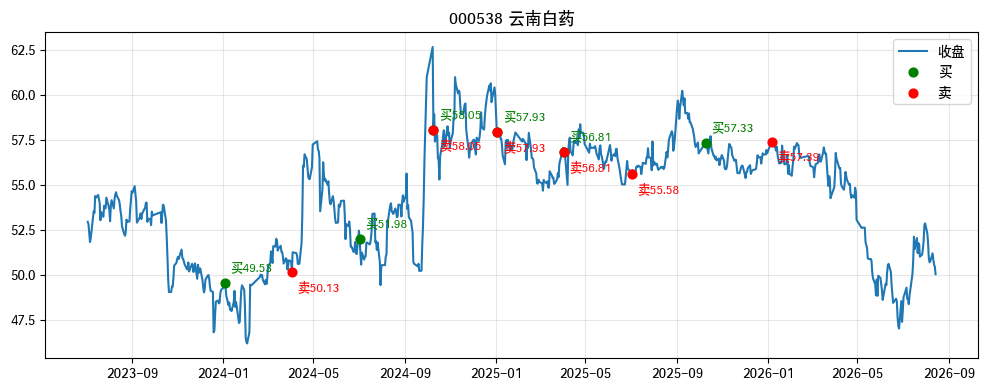

买入理由 2024-01-02 综合第20名 PE33.3 PB2.22 股息3.08% ROE6.7% Beta0.82 TTM增速-28.4% 市值886亿
买入理由 2024-07-01 综合第19名 PE26.1 PB2.27 股息3.96% ROE8.7% Beta0.83 TTM增速21.9% 市值942亿
买入理由 2024-10-08 综合第10名 PE25.8 PB2.84 股息3.31% ROE11.0% Beta0.87 TTM增速72.9% 市值1118亿
买入理由 2025-01-02 综合第12名 PE21.5 PB2.56 股息3.58% ROE11.9% Beta0.88 TTM增速81.2% 市值1036亿
买入理由 2025-04-01 综合第15名 PE24.9 PB2.51 股息3.64% ROE10.1% Beta0.86 TTM增速36.4% 市值1018亿
买入理由 2025-10-09 综合第19名 PE22.5 PB2.53 股息1.78% ROE11.2% Beta0.83 TTM增速1.9% 市值1023亿
买2024-01-03@49.53 卖2024-04-02@50.13 季度全卖 收益1.13%
买2024-07-02@51.98 卖2024-10-09@58.05 季度全卖 收益11.59%
买2024-10-09@58.05 卖2025-01-03@57.93 季度全卖 收益1.59%
买2025-01-03@57.93 卖2025-04-02@56.81 季度全卖 收益-2.01%
买2025-04-02@56.81 卖2025-07-02@55.58 季度全卖 收益-0.58%
买2025-10-10@57.33 卖2026-01-06@57.39 季度全卖 收益0.02%
合计: 投入132652 收回135063 总收益1.82%
---


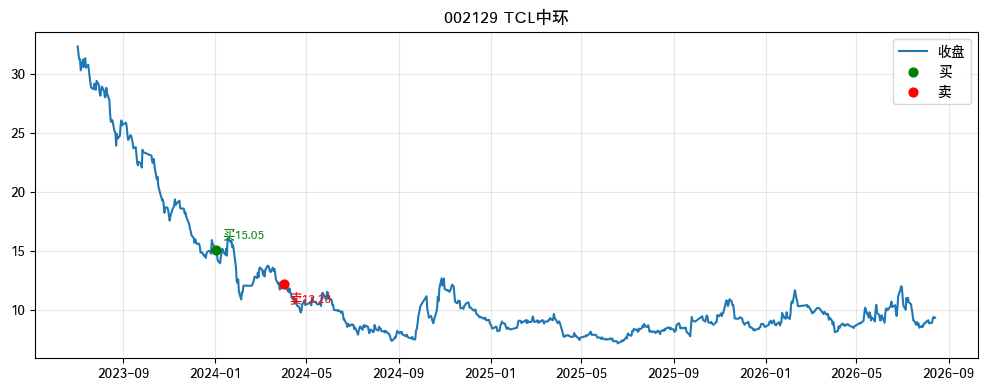

买入理由 2024-01-02 综合第19名 PE9.8 PB1.4 股息0.66% ROE14.3% Beta1.02 TTM增速108.0% 市值613亿
买2024-01-03@15.05 卖2024-04-02@12.23 季度全卖 收益-18.80%
合计: 投入22575 收回18330 总收益-18.80%
---


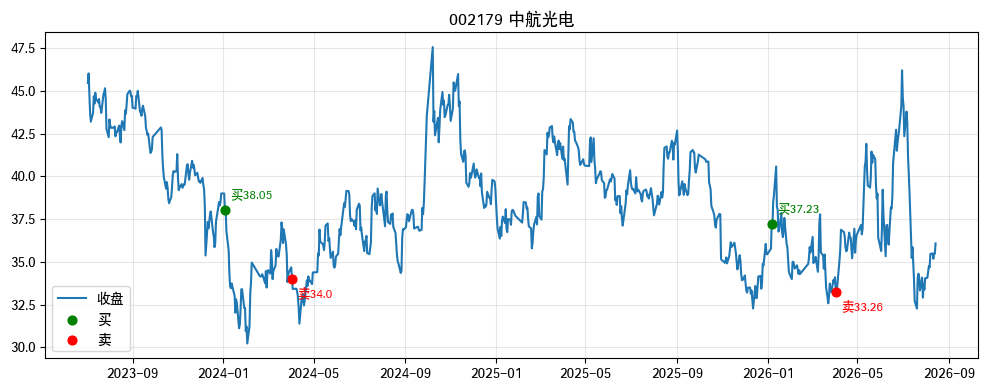

买入理由 2024-01-02 综合第18名 PE31.2 PB4.16 股息1.41% ROE13.3% Beta0.66 TTM增速35.2% 市值827亿
买入理由 2026-01-05 综合第19名 PE29.6 PB3.19 股息2.24% ROE10.8% Beta0.83 TTM增速-13.4% 市值758亿
买2024-01-03@38.05 卖2024-04-02@34.0 季度全卖 收益-10.72%
买2026-01-06@37.23 卖2026-04-02@33.26 季度全卖 收益-10.74%
合计: 投入45168 收回40323 总收益-10.73%
---


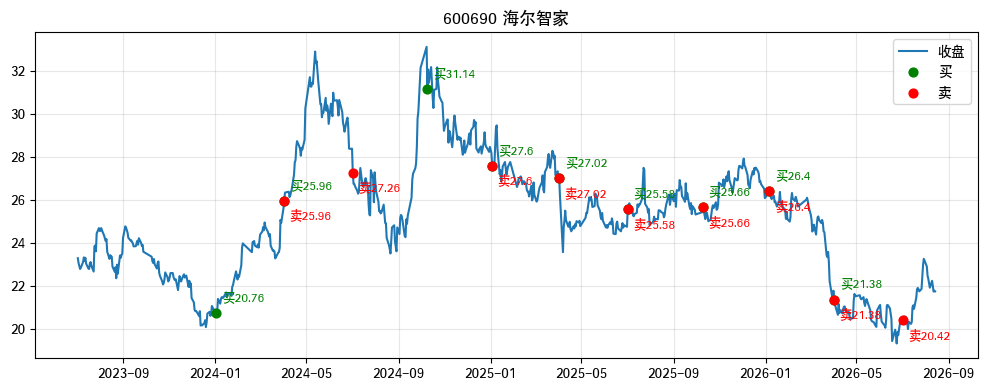

买入理由 2024-01-02 综合第17名 PE13.3 PB1.96 股息2.73% ROE14.8% Beta1.09 TTM增速18.1% 市值1962亿
买入理由 2024-04-01 综合第18名 PE16.4 PB2.41 股息2.21% ROE14.7% Beta0.93 TTM增速12.5% 市值2418亿
买入理由 2024-10-08 综合第18名 PE19.9 PB2.96 股息2.42% ROE14.9% Beta0.83 TTM增速10.8% 市值3126亿
买入理由 2025-01-02 综合第14名 PE16.3 PB2.42 股息2.84% ROE14.8% Beta0.83 TTM增速9.4% 市值2646亿
买入理由 2025-04-01 综合第12名 PE15.2 PB2.31 股息2.97% ROE15.2% Beta0.86 TTM增速12.8% 市值2529亿
买入理由 2025-07-01 综合第15名 PE13.4 PB1.97 股息3.24% ROE14.8% Beta0.95 TTM增速14.7% 市值2323亿
买入理由 2025-10-09 综合第3名 PE13.1 PB2.08 股息3.79% ROE15.9% Beta0.91 TTM增速1.0% 市值2387亿
买入理由 2026-01-05 综合第13名 PE13.1 PB2.07 股息1.02% ROE15.7% Beta0.91 TTM增速1.2% 市值2470亿
买入理由 2026-04-01 综合第9名 PE10.5 PB1.71 股息1.24% ROE16.4% Beta0.91 TTM增速4.4% 市值2045亿
买2024-01-03@20.76 卖2024-04-02@25.96 季度全卖 收益24.95%
买2024-04-02@25.96 卖2024-07-02@27.26 季度全卖 收益4.92%
买2024-10-09@31.14 卖2025-01-03@27.6 季度全卖 收益-11.44%
买2025-01-03@27.6 卖2025-04-02@27.02 季度全卖 收益-2.18%
买2025-04-02@27.02 卖2025-07-02@25.58 季度全卖 收益-5.41%
买2025-07-02@25.58 卖2

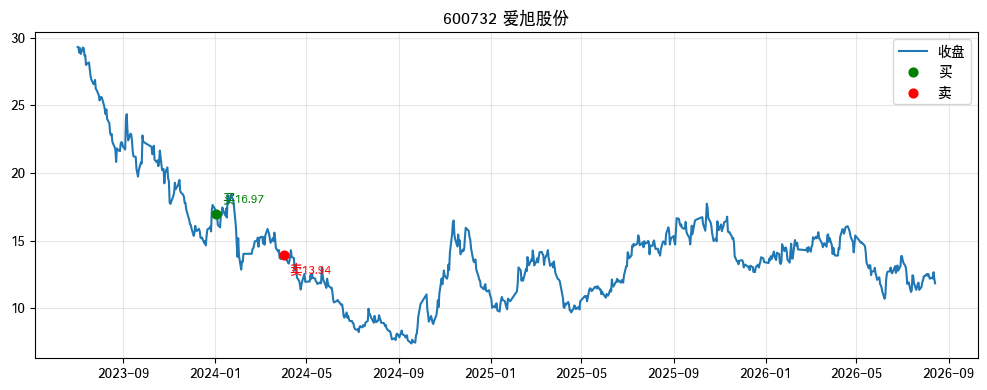

买入理由 2024-01-02 综合第9名 PE24.1 PB3.15 股息3.19% ROE13.1% Beta0.83 TTM增速239.9% 市值315亿
买2024-01-03@16.97 卖2024-04-02@13.94 季度全卖 收益-17.92%
合计: 投入22061 收回18107 总收益-17.92%
---


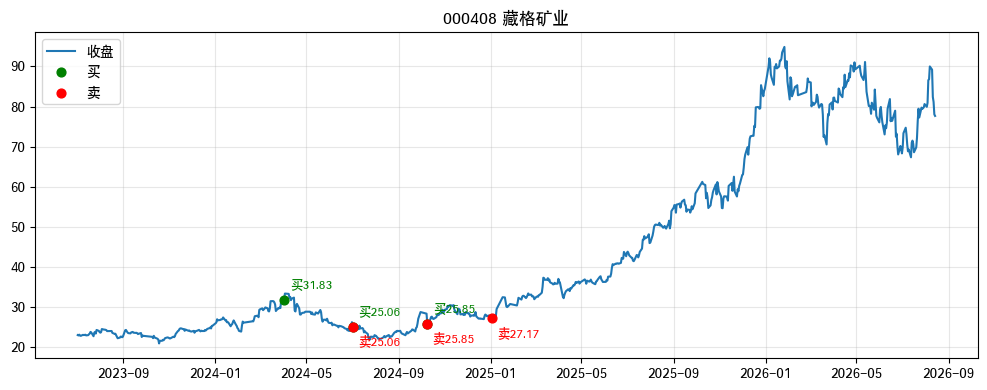

买入理由 2024-04-01 综合第12名 PE8.9 PB4.04 股息2.52% ROE45.6% Beta0.96 TTM增速296.2% 市值501亿
买入理由 2024-07-01 综合第5名 PE7.2 PB3.05 股息3.05% ROE42.4% Beta0.99 TTM增速189.7% 市值415亿
买入理由 2024-10-08 综合第17名 PE8.5 PB3.41 股息0.92% ROE40.3% Beta0.87 TTM增速56.4% 市值448亿
买2024-04-02@31.83 卖2024-07-02@25.06 季度全卖 收益-19.32%
买2024-07-02@25.06 卖2024-10-09@25.85 季度全卖 收益4.00%
买2024-10-09@25.85 卖2025-01-03@27.17 季度全卖 收益5.02%
合计: 投入68100 收回65865 总收益-3.28%
---


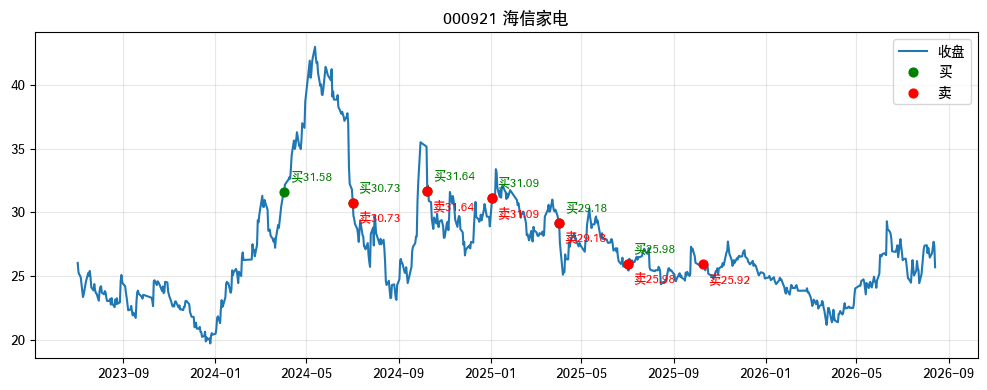

买入理由 2024-04-01 综合第20名 PE30.5 PB3.31 股息1.64% ROE10.9% Beta0.78 TTM增速47.5% 市值437亿
买入理由 2024-07-01 综合第18名 PE24.7 PB3.08 股息1.63% ROE12.5% Beta0.76 TTM增速74.8% 市值441亿
买入理由 2024-10-08 综合第11名 PE21.1 PB3.44 股息2.88% ROE16.3% Beta0.94 TTM增速136.6% 市值488亿
买入理由 2025-01-02 综合第8名 PE15.1 PB2.85 股息3.33% ROE18.9% Beta0.98 TTM增速150.1% 市值421亿
买入理由 2025-04-01 综合第6名 PE14.3 PB2.74 股息3.47% ROE19.2% Beta0.99 TTM增速97.7% 市值405亿
买入理由 2025-07-01 综合第9名 PE11.1 PB2.14 股息3.95% ROE19.3% Beta1.04 TTM增速79.5% 市值355亿
买2024-04-02@31.58 卖2024-07-02@30.73 季度全卖 收益-2.77%
买2024-07-02@30.73 卖2024-10-09@31.64 季度全卖 收益5.84%
买2024-10-09@31.64 卖2025-01-03@31.09 季度全卖 收益-1.82%
买2025-01-03@31.09 卖2025-04-02@29.18 季度全卖 收益-6.22%
买2025-04-02@29.18 卖2025-07-02@25.98 季度全卖 收益-11.04%
买2025-07-02@25.98 卖2025-10-10@25.92 季度全卖 收益3.95%
合计: 投入131656 收回128787 总收益-2.18%
---


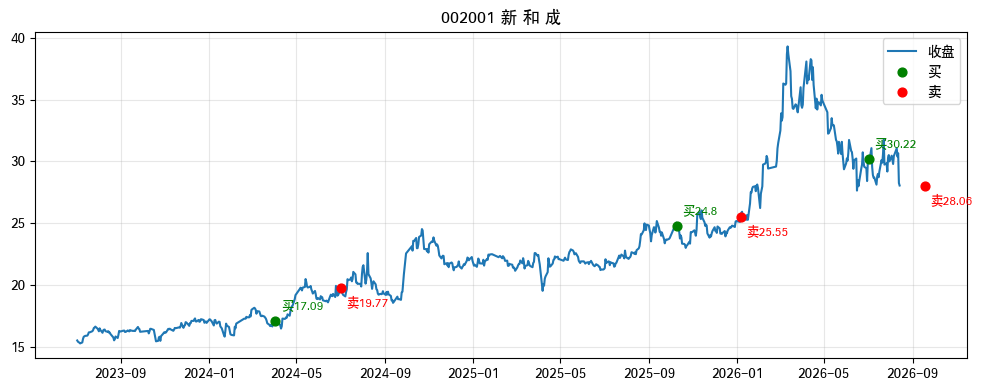

买入理由 2024-04-01 综合第13名 PE13.3 PB2.18 股息2.93% ROE16.4% Beta0.79 TTM增速-1.1% 市值528亿
买入理由 2025-10-09 综合第6名 PE18.8 PB2.53 股息2.00% ROE13.5% Beta0.82 TTM增速19.8% 市值770亿
买入理由 2026-07-01 综合第7名 PE13.7 PB2.62 股息2.67% ROE19.1% Beta0.66 TTM增速-2.4% 市值921亿
买2024-04-02@17.09 卖2024-07-02@19.77 季度全卖 收益17.96%
买2025-10-10@24.8 卖2026-01-06@25.55 季度全卖 收益3.59%
买2026-07-02@30.22 卖2026-09-18@28.06 期末持有 收益-7.15%
合计: 投入62669 收回66162 总收益5.57%
---


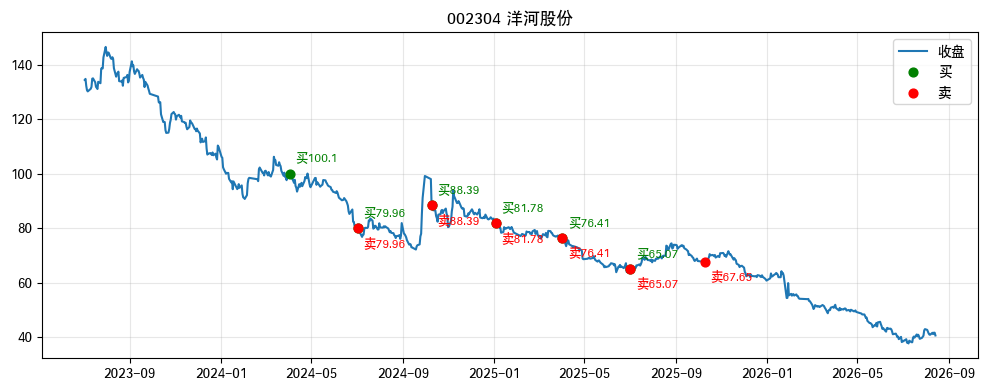

买入理由 2024-04-01 综合第19名 PE16.2 PB2.92 股息3.71% ROE18.0% Beta1.11 TTM增速24.7% 市值1521亿
买入理由 2024-07-01 综合第15名 PE11.9 PB2.09 股息5.78% ROE17.5% Beta1.12 TTM增速17.7% 市值1214亿
买入理由 2024-10-08 综合第19名 PE14.3 PB2.79 股息4.75% ROE19.6% Beta1.07 TTM增速18.4% 市值1477亿
买入理由 2025-01-02 综合第13名 PE11.7 PB2.29 股息5.73% ROE19.7% Beta1.06 TTM增速12.2% 市值1224亿
买入理由 2025-04-01 综合第14名 PE11.0 PB2.15 股息6.10% ROE19.7% Beta1.02 TTM增速12.2% 市值1151亿
买入理由 2025-07-01 综合第13名 PE9.4 PB1.88 股息3.58% ROE19.9% Beta0.99 TTM增速1.4% 市值974亿
买2024-04-02@100.1 卖2024-07-02@79.96 季度全卖 收益-16.00%
买2024-07-02@79.96 卖2024-10-09@88.39 季度全卖 收益10.45%
买2024-10-09@88.39 卖2025-01-03@81.78 季度全卖 收益-7.55%
买2025-01-03@81.78 卖2025-04-02@76.41 季度全卖 收益-4.37%
买2025-04-02@76.41 卖2025-07-02@65.07 季度全卖 收益-12.18%
买2025-07-02@65.07 卖2025-10-10@67.65 季度全卖 收益3.88%
合计: 投入112490 收回106875 总收益-4.99%
---


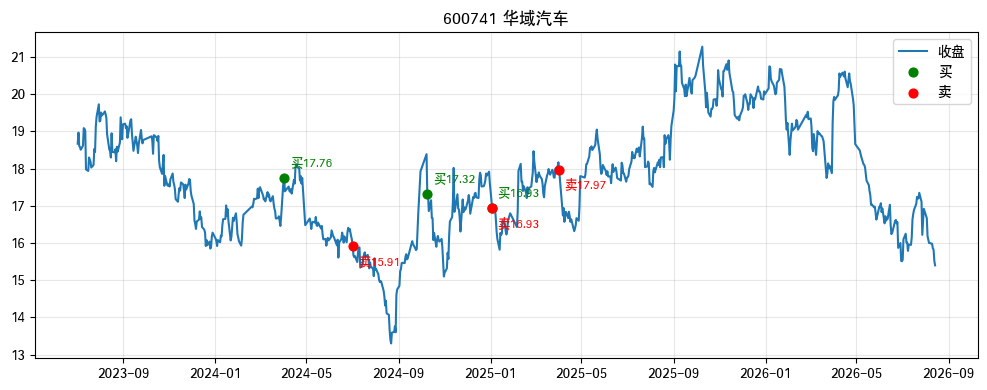

买入理由 2024-04-01 综合第9名 PE7.7 PB1.01 股息4.99% ROE13.0% Beta0.9 TTM增速11.3% 市值556亿
买入理由 2024-10-08 综合第4名 PE7.7 PB1.0 股息4.08% ROE13.0% Beta0.83 TTM增速20.3% 市值580亿
买入理由 2025-01-02 综合第5名 PE7.7 PB0.9 股息4.37% ROE11.8% Beta0.83 TTM增速6.3% 市值542亿
买2024-04-02@17.76 卖2024-07-02@15.91 季度全卖 收益-10.49%
买2024-10-09@17.32 卖2025-01-03@16.93 季度全卖 收益-2.33%
买2025-01-03@16.93 卖2025-04-02@17.97 季度全卖 收益6.06%
合计: 投入69262 收回67898 总收益-1.97%
---


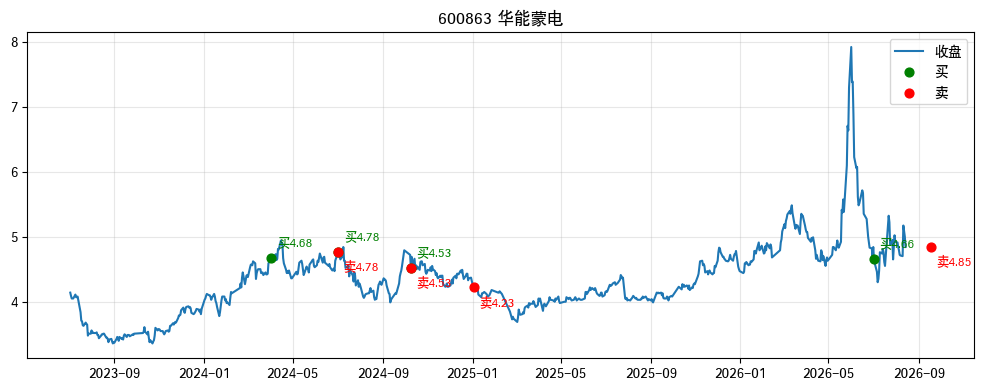

买入理由 2024-04-01 综合第4名 PE21.0 PB1.68 股息3.53% ROE8.0% Beta0.59 TTM增速159.4% 市值304亿
买入理由 2024-07-01 综合第2名 PE14.5 PB1.6 股息3.46% ROE11.0% Beta0.63 TTM增速159.5% 市值309亿
买入理由 2024-10-08 综合第2名 PE14.8 PB1.62 股息3.91% ROE10.9% Beta0.65 TTM增速76.0% 市值309亿
买入理由 2026-07-01 综合第10名 PE16.8 PB1.74 股息4.54% ROE10.4% Beta0.6 TTM增速-26.2% 市值380亿
买2024-04-02@4.68 卖2024-07-02@4.78 季度全卖 收益2.05%
买2024-07-02@4.78 卖2024-10-09@4.53 季度全卖 收益-2.21%
买2024-10-09@4.53 卖2025-01-03@4.23 季度全卖 收益-6.70%
买2026-07-02@4.66 卖2026-09-18@4.85 期末持有 收益7.85%
合计: 投入89923 收回89852 总收益-0.08%
---


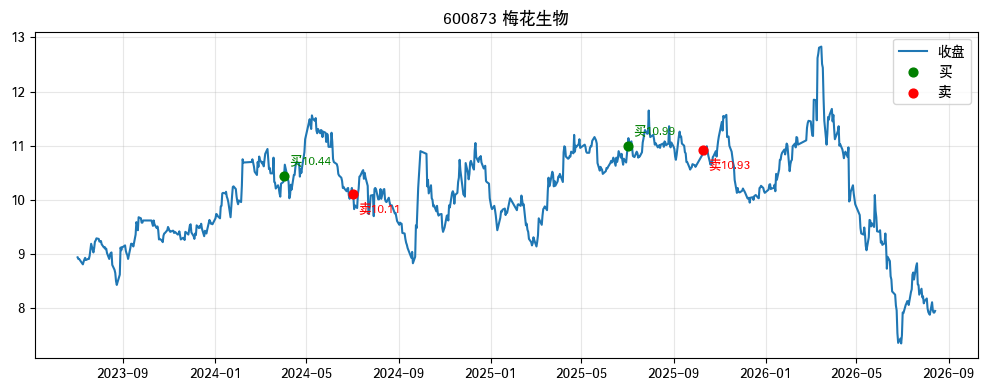

买入理由 2024-04-01 综合第1名 PE6.9 PB2.14 股息3.87% ROE31.1% Beta0.72 TTM增速83.4% 市值304亿
买入理由 2025-07-01 综合第1名 PE9.9 PB2.0 股息3.93% ROE20.3% Beta0.78 TTM增速-22.6% 市值310亿
买2024-04-02@10.44 卖2024-07-02@10.11 季度全卖 收益0.38%
买2025-07-02@10.99 卖2025-10-10@10.93 季度全卖 收益-0.63%
合计: 投入44948 收回44897 总收益-0.11%
---


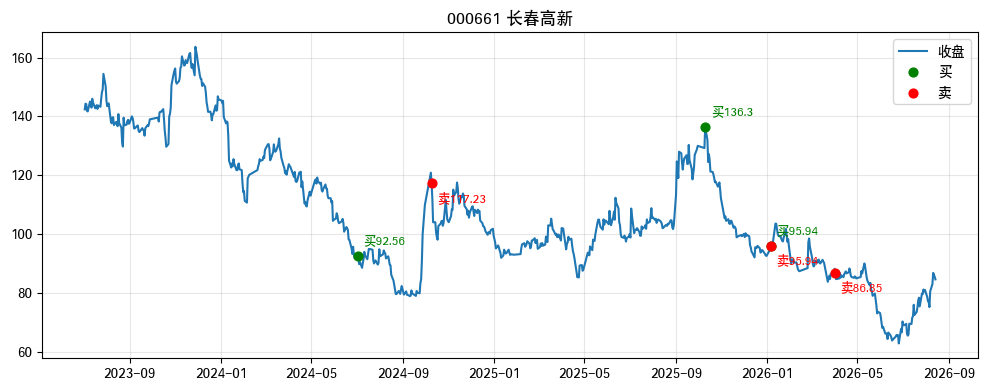

买入理由 2024-07-01 综合第16名 PE9.8 PB1.65 股息4.82% ROE16.9% Beta1.15 TTM增速-4.0% 市值377亿
买入理由 2025-10-09 综合第20名 PE13.9 PB2.31 股息2.01% ROE16.6% Beta1.06 TTM增速-7.2% 市值527亿
买入理由 2026-01-05 综合第8名 PE13.3 PB1.68 股息2.74% ROE12.6% Beta0.9 TTM增速-21.6% 市值387亿
买2024-07-02@92.56 卖2024-10-09@117.23 季度全卖 收益26.55%
买2025-10-10@136.3 卖2026-01-06@95.94 季度全卖 收益-29.68%
买2026-01-06@95.94 卖2026-04-02@86.85 季度全卖 收益-9.55%
合计: 投入51330 收回50367 总收益-1.88%
---


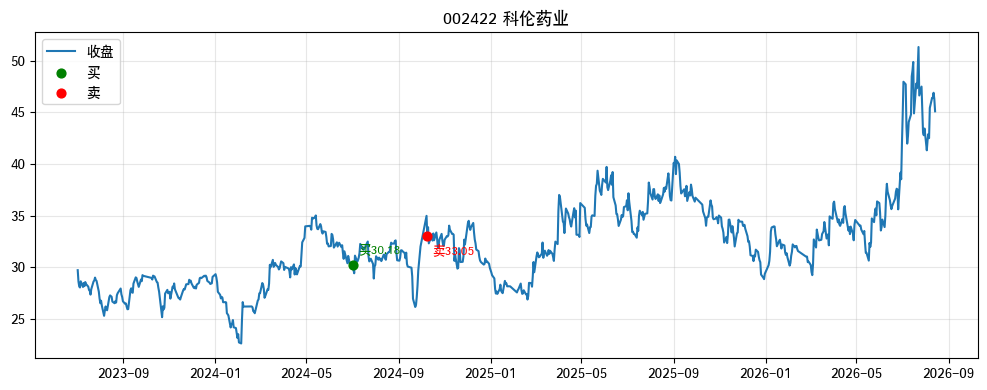

买入理由 2024-07-01 综合第17名 PE21.9 PB2.19 股息2.63% ROE10.0% Beta0.92 TTM增速82.9% 市值488亿
买2024-07-02@30.18 卖2024-10-09@33.05 季度全卖 收益9.42%
合计: 投入21126 收回23116 总收益9.42%
---


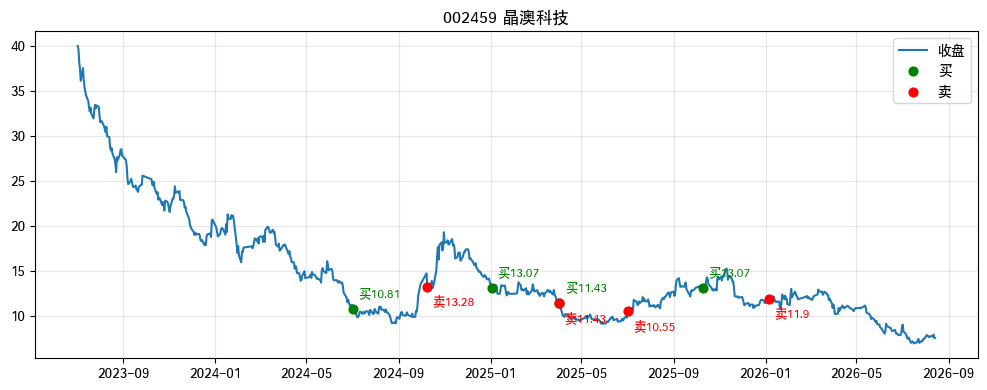

买入理由 2024-07-01 综合第14名 PE5.1 PB1.07 股息5.00% ROE21.2% Beta1.47 TTM增速179.9% 市值372亿
买入理由 2025-01-02 综合第17名 PE4.9 PB1.4 股息4.19% ROE28.4% Beta1.32 TTM增速124.3% 市值444亿
买入理由 2025-04-01 综合第13名 PE4.2 PB1.2 股息4.89% ROE28.4% Beta1.26 TTM增速124.3% 市值381亿
买入理由 2025-10-09 综合第9名 PE8.3 PB1.79 股息4.20% ROE21.5% Beta1.21 TTM增速294.5% 市值444亿
买2024-07-02@10.81 卖2024-10-09@13.28 季度全卖 收益22.75%
买2025-01-03@13.07 卖2025-04-02@11.43 季度全卖 收益-12.62%
买2025-04-02@11.43 卖2025-07-02@10.55 季度全卖 收益-7.77%
买2025-10-10@13.07 卖2026-01-06@11.9 季度全卖 收益-9.03%
合计: 投入92613 收回90908 总收益-1.84%
---


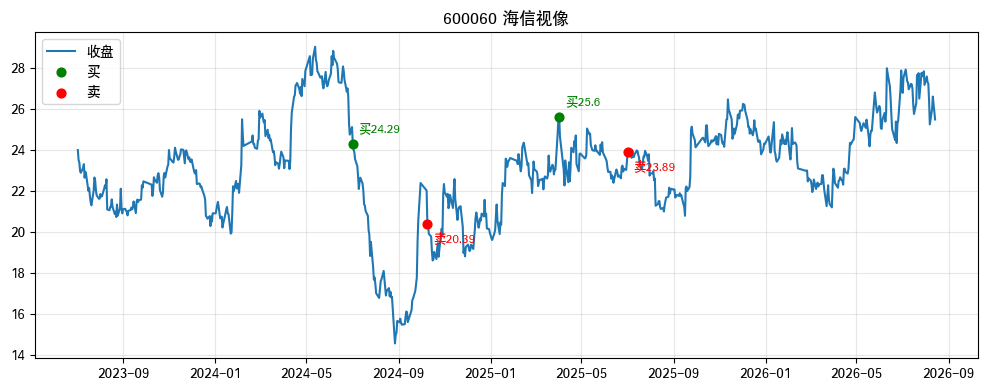

买入理由 2024-07-01 综合第13名 PE16.4 PB1.71 股息2.56% ROE10.5% Beta0.91 TTM增速62.3% 市值328亿
买入理由 2025-04-01 综合第10名 PE15.9 PB1.78 股息3.15% ROE11.2% Beta0.87 TTM增速24.8% 市值334亿
买2024-07-02@24.29 卖2024-10-09@20.39 季度全卖 收益-13.47%
买2025-04-02@25.6 卖2025-07-02@23.89 季度全卖 收益-6.76%
合计: 投入44901 收回40399 总收益-10.03%
---


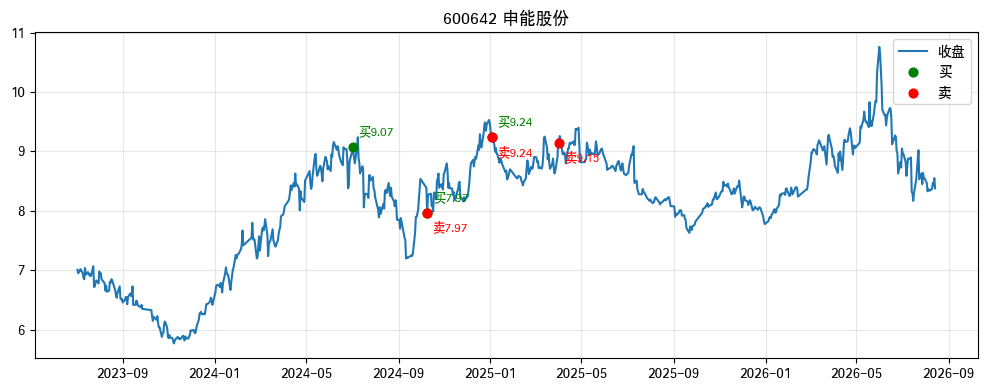

买入理由 2024-07-01 综合第3名 PE27.2 PB1.23 股息4.45% ROE4.5% Beta0.52 TTM增速86.5% 市值440亿
买入理由 2024-10-08 综合第1名 PE19.4 PB1.18 股息4.77% ROE6.1% Beta0.6 TTM增速159.1% 市值411亿
买入理由 2025-01-02 综合第1名 PE18.6 PB1.22 股息4.32% ROE6.6% Beta0.64 TTM增速547.4% 市值453亿
买2024-07-02@9.07 卖2024-10-09@7.97 季度全卖 收益-12.20%
买2024-10-09@7.97 卖2025-01-03@9.24 季度全卖 收益15.84%
买2025-01-03@9.24 卖2025-04-02@9.15 季度全卖 收益-1.05%
合计: 投入70609 收回71378 总收益1.09%
---


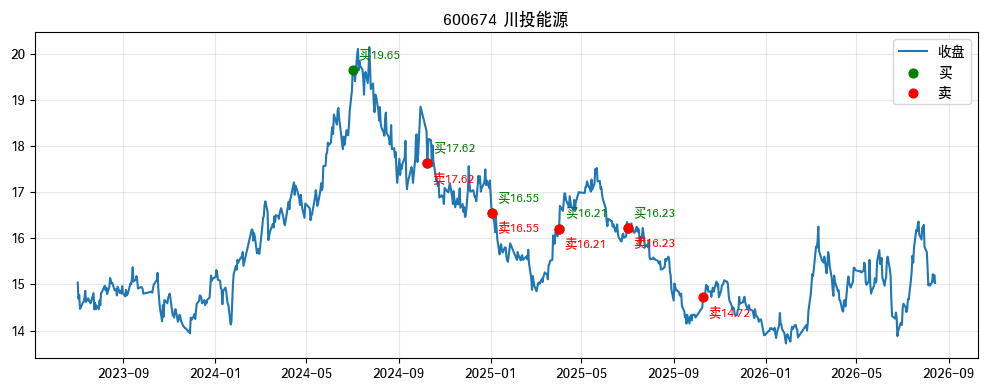

买入理由 2024-07-01 综合第12名 PE22.9 PB2.29 股息2.08% ROE10.0% Beta0.41 TTM增速36.5% 市值936亿
买入理由 2024-10-08 综合第13名 PE22.0 PB2.24 股息2.18% ROE10.2% Beta0.46 TTM增速21.5% 市值893亿
买入理由 2025-01-02 综合第7名 PE18.3 PB1.93 股息2.40% ROE10.5% Beta0.51 TTM增速37.5% 市值813亿
买入理由 2025-04-01 综合第5名 PE17.8 PB1.88 股息2.47% ROE10.5% Beta0.51 TTM增速37.5% 市值790亿
买入理由 2025-07-01 综合第16名 PE17.6 PB1.83 股息2.45% ROE10.4% Beta0.52 TTM增速10.8% 市值797亿
买2024-07-02@19.65 卖2024-10-09@17.62 季度全卖 收益-8.78%
买2024-10-09@17.62 卖2025-01-03@16.55 季度全卖 收益-6.15%
买2025-01-03@16.55 卖2025-04-02@16.21 季度全卖 收益-2.13%
买2025-04-02@16.21 卖2025-07-02@16.23 季度全卖 收益0.04%
买2025-07-02@16.23 卖2025-10-10@14.72 季度全卖 收益-7.41%
合计: 投入113107 收回107635 总收益-4.84%
---


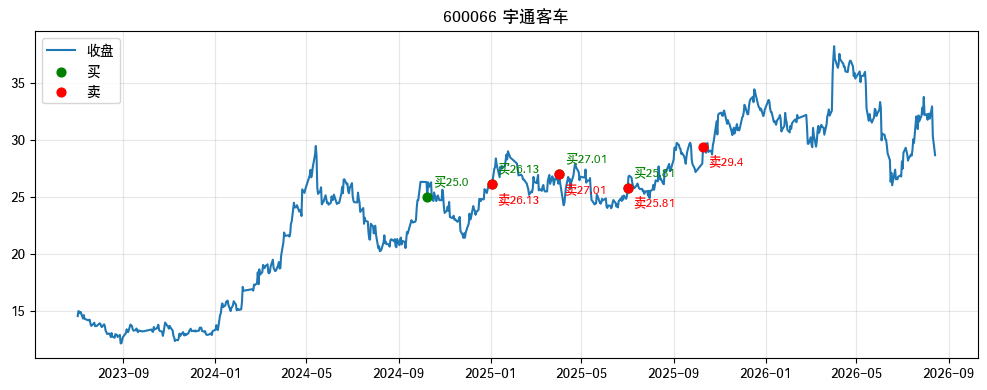

买入理由 2024-10-08 综合第20名 PE45.0 PB4.78 股息5.70% ROE10.6% Beta0.88 TTM增速220.8% 市值583亿
买入理由 2025-01-02 综合第15名 PE34.0 PB4.4 股息5.81% ROE12.9% Beta0.89 TTM增速247.6% 市值571亿
买入理由 2025-04-01 综合第8名 PE31.9 PB4.47 股息5.73% ROE14.0% Beta0.85 TTM增速139.4% 市值580亿
买入理由 2025-07-01 综合第6名 PE23.6 PB3.93 股息3.98% ROE16.6% Beta0.81 TTM增速136.5% 市值556亿
买2024-10-09@25.0 卖2025-01-03@26.13 季度全卖 收益6.23%
买2025-01-03@26.13 卖2025-04-02@27.01 季度全卖 收益3.28%
买2025-04-02@27.01 卖2025-07-02@25.81 季度全卖 收益-1.19%
买2025-07-02@25.81 卖2025-10-10@29.4 季度全卖 收益15.56%
合计: 投入88273 收回93404 总收益5.81%
---


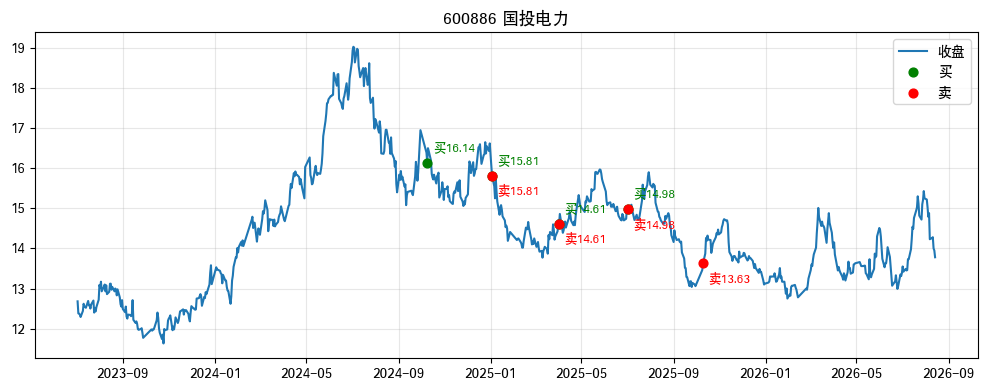

买入理由 2024-10-08 综合第6名 PE24.1 PB2.03 股息3.02% ROE8.4% Beta0.45 TTM增速105.8% 市值1222亿
买入理由 2025-01-02 综合第4名 PE20.0 PB1.9 股息3.08% ROE9.5% Beta0.48 TTM增速93.4% 市值1199亿
买入理由 2025-04-01 综合第3名 PE18.3 PB1.74 股息3.36% ROE9.5% Beta0.48 TTM增速93.4% 市值1097亿
买入理由 2025-07-01 综合第3名 PE16.9 PB1.69 股息3.30% ROE10.0% Beta0.52 TTM增速53.0% 市值1201亿
买2024-10-09@16.14 卖2025-01-03@15.81 季度全卖 收益-2.12%
买2025-01-03@15.81 卖2025-04-02@14.61 季度全卖 收益-7.66%
买2025-04-02@14.61 卖2025-07-02@14.98 季度全卖 收益2.45%
买2025-07-02@14.98 卖2025-10-10@13.63 季度全卖 收益-6.35%
合计: 投入93771 收回90586 总收益-3.40%
---


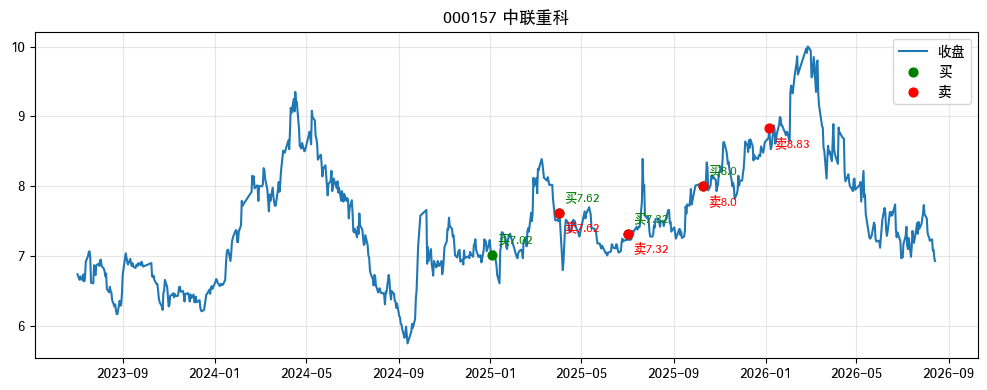

买入理由 2025-01-02 综合第20名 PE20.3 PB1.06 股息4.57% ROE5.2% Beta0.96 TTM增速11.3% 市值607亿
买入理由 2025-04-01 综合第20名 PE18.6 PB1.14 股息4.27% ROE6.1% Beta1.0 TTM增速52.0% 市值651亿
买入理由 2025-07-01 综合第20名 PE17.4 PB1.08 股息4.43% ROE6.2% Beta1.04 TTM增速63.4% 市值627亿
买入理由 2025-10-09 综合第13名 PE17.5 PB1.22 股息3.73% ROE7.0% Beta1.0 TTM增速6.1% 市值695亿
买2025-01-03@7.02 卖2025-04-02@7.62 季度全卖 收益8.46%
买2025-04-02@7.62 卖2025-07-02@7.32 季度全卖 收益-4.01%
买2025-07-02@7.32 卖2025-10-10@8.0 季度全卖 收益12.48%
买2025-10-10@8.0 卖2026-01-06@8.83 季度全卖 收益10.29%
合计: 投入93382 收回99670 总收益6.73%
---


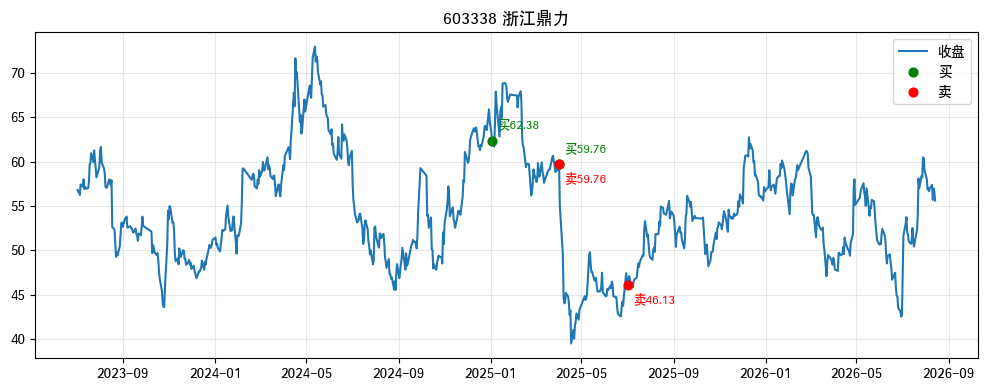

买入理由 2025-01-02 综合第19名 PE19.2 PB3.26 股息1.58% ROE17.0% Beta0.89 TTM增速62.4% 市值321亿
买入理由 2025-04-01 综合第16名 PE18.0 PB3.07 股息1.68% ROE17.0% Beta0.87 TTM增速62.4% 市值302亿
买2025-01-03@62.38 卖2025-04-02@59.76 季度全卖 收益-4.28%
买2025-04-02@59.76 卖2025-07-02@46.13 季度全卖 收益-21.37%
合计: 投入36642 收回32010 总收益-12.64%
---


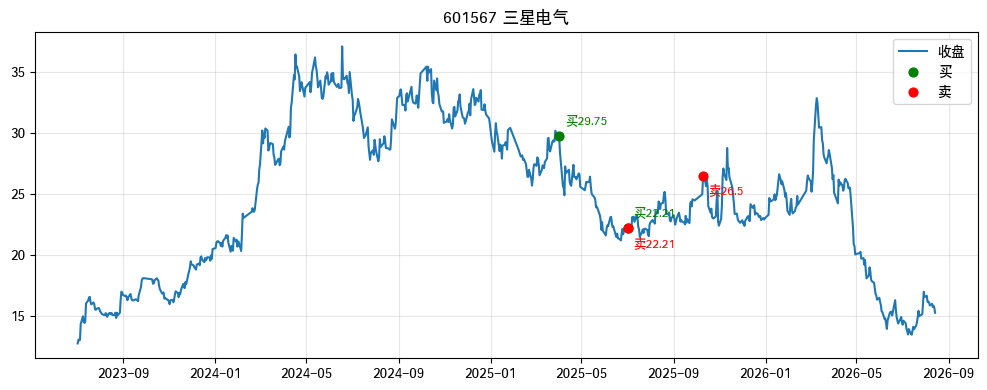

买入理由 2025-04-01 综合第11名 PE24.0 PB3.56 股息2.20% ROE14.8% Beta0.81 TTM增速139.6% 市值416亿
买入理由 2025-07-01 综合第2名 PE15.6 PB2.47 股息4.03% ROE15.9% Beta0.87 TTM增速89.8% 市值312亿
买2025-04-02@29.75 卖2025-07-02@22.21 季度全卖 收益-22.72%
买2025-07-02@22.21 卖2025-10-10@26.5 季度全卖 收益19.22%
合计: 投入43035 收回42573 总收益-1.07%
---


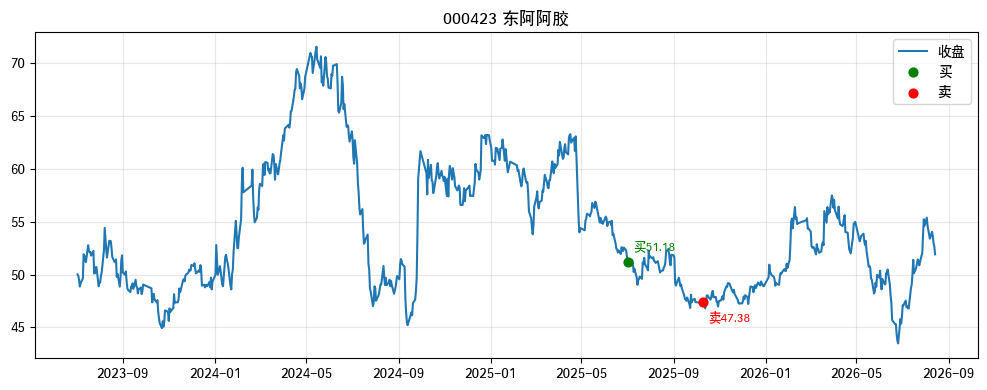

买入理由 2025-07-01 综合第18名 PE26.1 PB3.1 股息2.46% ROE11.9% Beta0.73 TTM增速42.2% 市值333亿
买2025-07-02@51.18 卖2025-10-10@47.38 季度全卖 收益-5.27%
合计: 投入20472 收回19394 总收益-5.27%
---


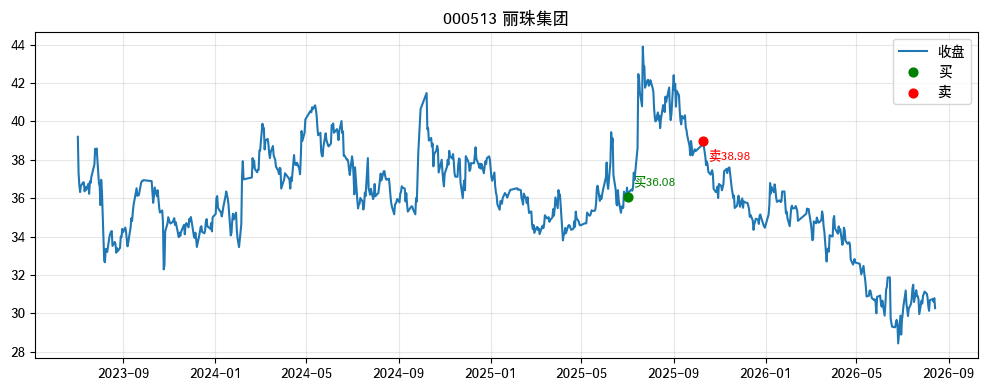

买入理由 2025-07-01 综合第17名 PE16.8 PB2.35 股息3.01% ROE14.0% Beta0.78 TTM增速2.1% 市值333亿
买2025-07-02@36.08 卖2025-10-10@38.98 季度全卖 收益7.95%
合计: 投入21648 收回23369 总收益7.95%
---


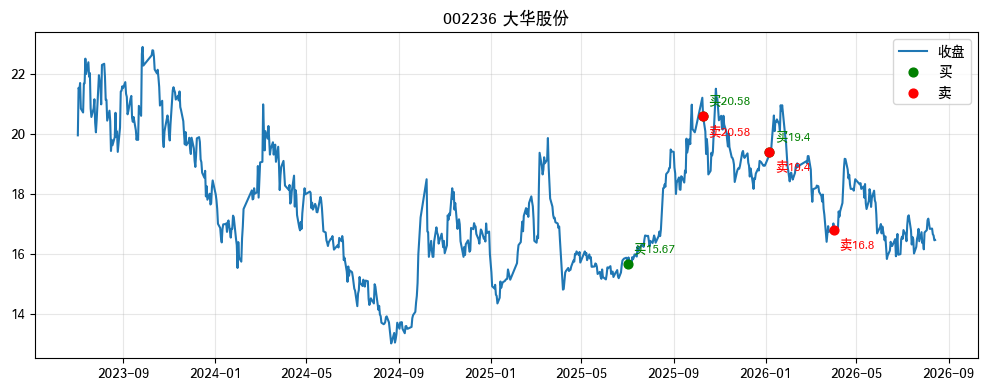

买入理由 2025-07-01 综合第14名 PE7.0 PB1.42 股息2.89% ROE20.2% Beta1.14 TTM增速201.4% 市值522亿
买入理由 2025-10-09 综合第10名 PE9.7 PB1.88 股息2.16% ROE19.4% Beta1.11 TTM增速158.8% 市值696亿
买入理由 2026-01-05 综合第7名 PE7.6 PB1.65 股息2.38% ROE21.9% Beta1.21 TTM增速14.1% 市值632亿
买2025-07-02@15.67 卖2025-10-10@20.58 季度全卖 收益31.23%
买2025-10-10@20.58 卖2026-01-06@19.4 季度全卖 收益-5.00%
买2026-01-06@19.4 卖2026-04-02@16.8 季度全卖 收益-13.47%
合计: 投入67856 收回70439 总收益3.81%
---


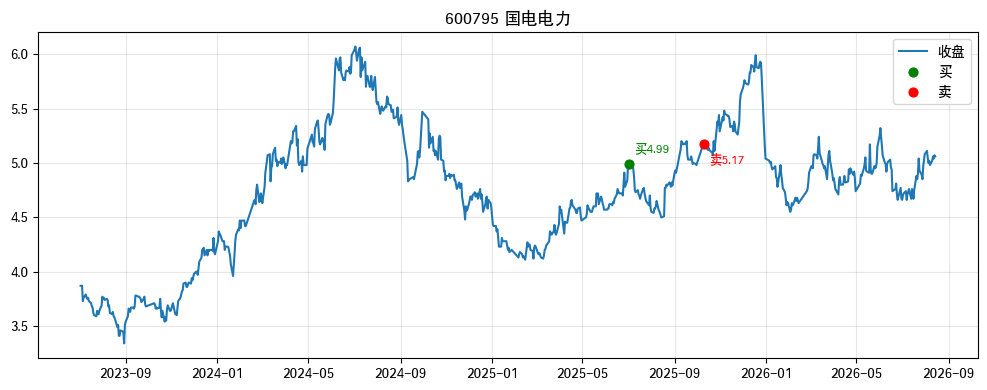

买入理由 2025-07-01 综合第8名 PE13.8 PB1.54 股息1.80% ROE11.1% Beta0.69 TTM增速137.8% 市值890亿
买2025-07-02@4.99 卖2025-10-10@5.17 季度全卖 收益5.29%
合计: 投入22455 收回23642 总收益5.29%
---


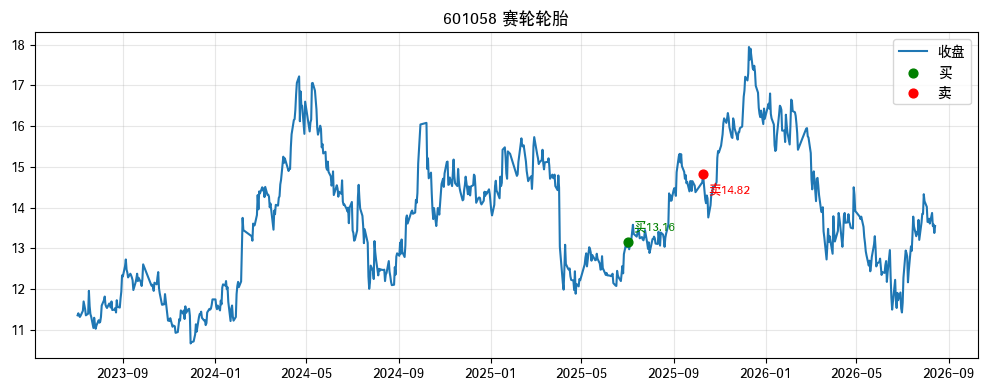

买入理由 2025-07-01 综合第10名 PE11.4 PB2.09 股息1.77% ROE18.4% Beta0.91 TTM增速176.1% 市值428亿
买2025-07-02@13.16 卖2025-10-10@14.82 季度全卖 收益13.55%
合计: 投入22372 收回25403 总收益13.55%
---


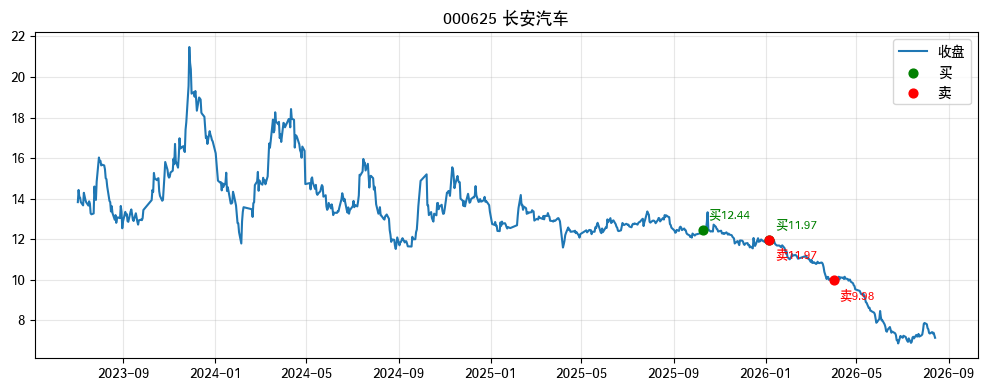

买入理由 2025-10-09 综合第8名 PE11.3 PB1.61 股息2.39% ROE14.2% Beta1.01 TTM增速65.8% 市值1221亿
买入理由 2026-01-05 综合第15名 PE10.9 PB1.52 股息0.42% ROE14.0% Beta0.92 TTM增速115.0% 市值1173亿
买2025-10-10@12.44 卖2026-01-06@11.97 季度全卖 收益-3.49%
买2026-01-06@11.97 卖2026-04-02@9.98 季度全卖 收益-16.69%
合计: 投入46379 收回41757 总收益-9.97%
---


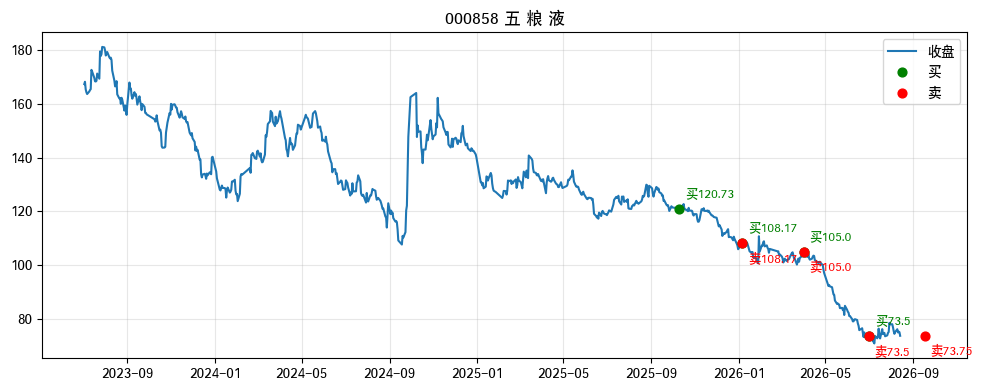

买入理由 2025-10-09 综合第15名 PE15.6 PB3.45 股息2.62% ROE22.1% Beta1.06 TTM增速13.2% 市值4703亿
买入理由 2026-01-05 综合第2名 PE13.9 PB3.07 股息2.94% ROE22.1% Beta0.8 TTM增速13.2% 市值4188亿
买入理由 2026-04-01 综合第3名 PE13.4 PB2.97 股息3.04% ROE22.1% Beta0.76 TTM增速13.2% 市值4052亿
买入理由 2026-07-01 综合第15名 PE23.0 PB2.26 股息4.25% ROE9.8% Beta0.62 TTM增速-43.3% 市值2893亿
买2025-10-10@120.73 卖2026-01-06@108.17 季度全卖 收益-8.57%
买2026-01-06@108.17 卖2026-04-02@105.0 季度全卖 收益-3.01%
买2026-04-02@105.0 卖2026-07-02@73.5 季度全卖 收益-30.06%
买2026-07-02@73.5 卖2026-09-18@73.75 期末持有 收益3.15%
合计: 投入69407 收回61872 总收益-10.86%
---


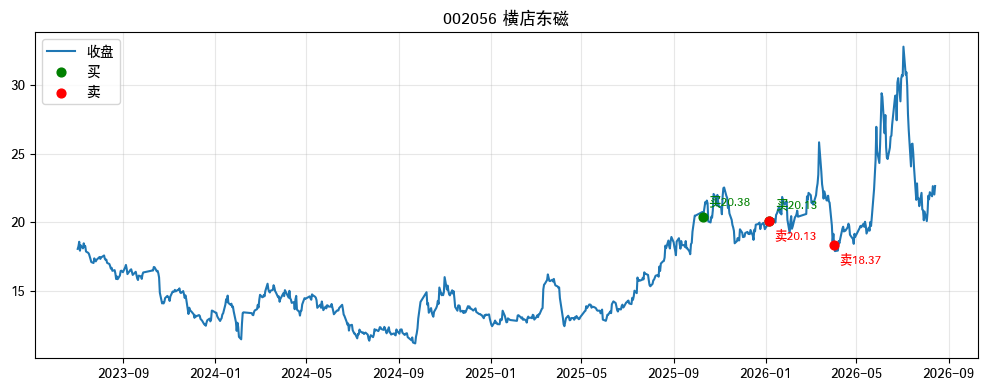

买入理由 2025-10-09 综合第12名 PE15.4 PB3.24 股息1.83% ROE21.1% Beta1.03 TTM增速76.0% 市值338亿
买入理由 2026-01-05 综合第10名 PE13.8 PB3.16 股息1.91% ROE22.9% Beta1.16 TTM增速114.3% 市值324亿
买2025-10-10@20.38 卖2026-01-06@20.13 季度全卖 收益-1.31%
买2026-01-06@20.13 卖2026-04-02@18.37 季度全卖 收益-8.82%
合计: 投入44561 收回42316 总收益-5.04%
---


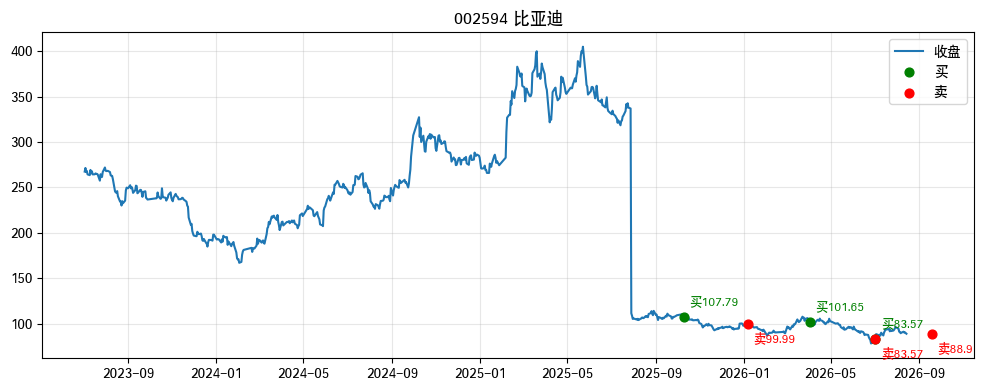

买入理由 2025-10-09 综合第17名 PE10.5 PB1.45 股息3.59% ROE13.8% Beta1.05 TTM增速-2.4% 市值3361亿
买入理由 2026-04-01 综合第18名 PE28.7 PB3.81 股息3.87% ROE13.3% Beta0.9 TTM增速-19.0% 市值9359亿
买入理由 2026-07-01 综合第18名 PE26.7 PB2.94 股息4.93% ROE11.0% Beta0.76 TTM增速-38.6% 市值7354亿
买2025-10-10@107.79 卖2026-01-06@99.99 季度全卖 收益-7.31%
买2026-04-02@101.65 卖2026-07-02@83.57 季度全卖 收益-17.85%
买2026-07-02@83.57 卖2026-09-18@88.9 期末持有 收益6.72%
合计: 投入58602 收回54519 总收益-6.97%
---


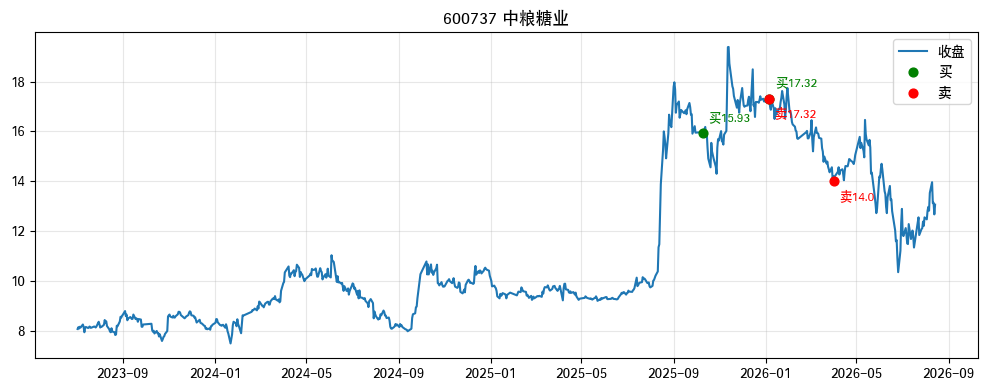

买入理由 2025-10-09 综合第18名 PE20.6 PB3.15 股息2.57% ROE15.3% Beta0.89 TTM增速-23.6% 市值342亿
买入理由 2026-01-05 综合第11名 PE21.3 PB3.25 股息2.39% ROE15.3% Beta0.89 TTM增速-3.8% 市值367亿
买2025-10-10@15.93 卖2026-01-06@17.32 季度全卖 收益8.64%
买2026-01-06@17.32 卖2026-04-02@14.0 季度全卖 收益-19.23%
合计: 投入44818 收回42413 总收益-5.37%
---


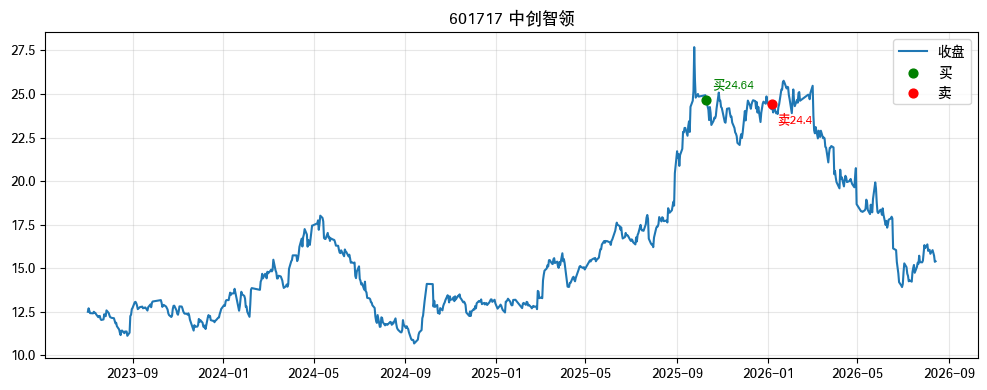

买入理由 2025-10-09 综合第4名 PE12.3 PB2.02 股息4.49% ROE16.5% Beta0.95 TTM增速-3.4% 市值445亿
买2025-10-10@24.64 卖2026-01-06@24.4 季度全卖 收益-1.05%
合计: 投入22176 收回21942 总收益-1.06%
---


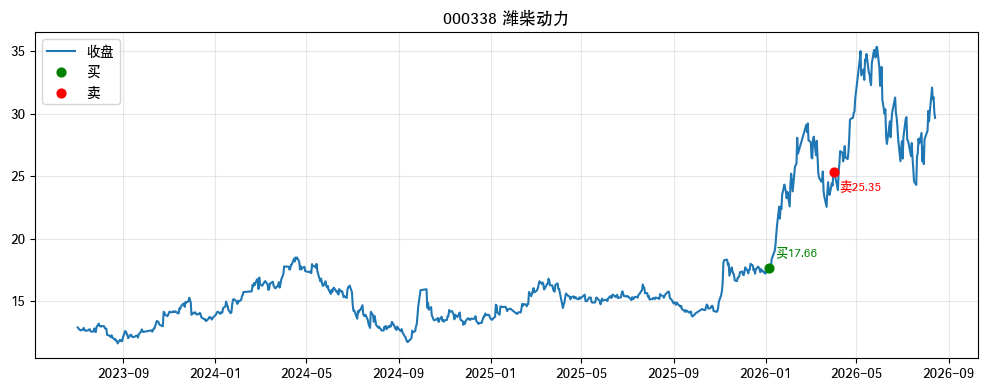

买入理由 2026-01-05 综合第17名 PE16.0 PB1.61 股息2.06% ROE10.1% Beta0.93 TTM增速-13.1% 市值1516亿
买2026-01-06@17.66 卖2026-04-02@25.35 季度全卖 收益43.43%
合计: 投入22958 收回32928 总收益43.43%
---


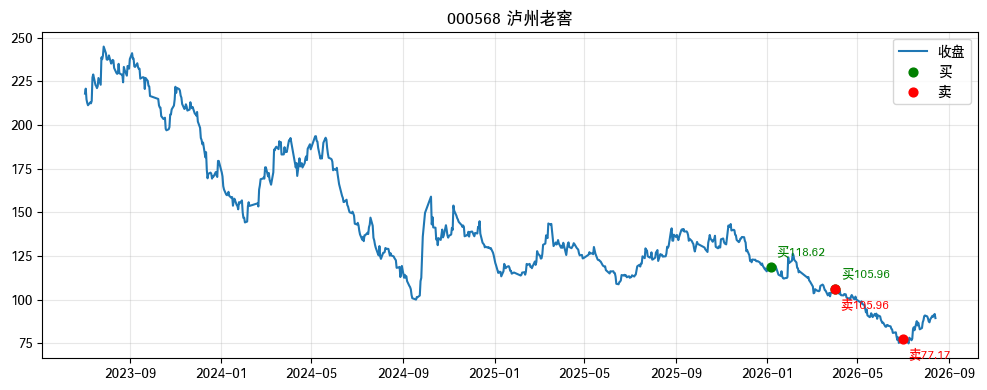

买入理由 2026-01-05 综合第4名 PE14.0 PB3.5 股息3.89% ROE25.0% Beta0.92 TTM增速-13.0% 市值1737亿
买入理由 2026-04-01 综合第5名 PE12.6 PB3.15 股息4.32% ROE25.0% Beta0.86 TTM增速-13.0% 市值1564亿
买2026-01-06@118.62 卖2026-04-02@105.96 季度全卖 收益-9.83%
买2026-04-02@105.96 卖2026-07-02@77.17 季度全卖 收益-27.23%
合计: 投入44916 收回36813 总收益-18.04%
---


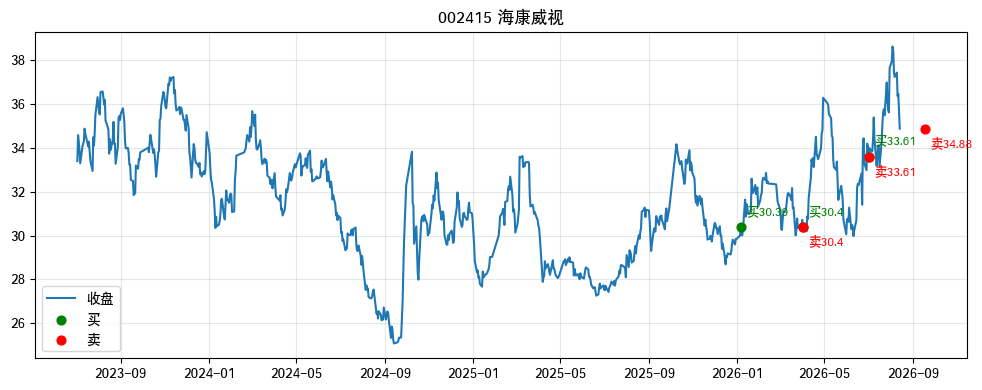

买入理由 2026-01-05 综合第14名 PE17.9 PB3.51 股息1.33% ROE19.5% Beta0.96 TTM增速14.6% 市值2749亿
买入理由 2026-04-01 综合第13名 PE18.4 PB3.59 股息1.30% ROE19.5% Beta0.91 TTM增速14.6% 市值2815亿
买入理由 2026-07-01 综合第14名 PE20.9 PB3.62 股息2.20% ROE17.4% Beta0.91 TTM增速23.4% 市值3119亿
买2026-01-06@30.39 卖2026-04-02@30.4 季度全卖 收益-0.05%
买2026-04-02@30.4 卖2026-07-02@33.61 季度全卖 收益12.69%
买2026-07-02@33.61 卖2026-09-18@34.88 期末持有 收益5.25%
合计: 投入62719 收回66468 总收益5.98%
---


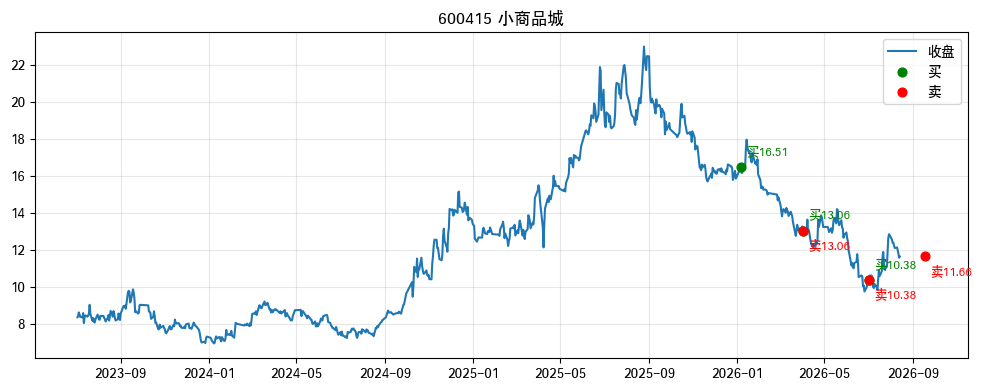

买入理由 2026-01-05 综合第18名 PE23.6 PB4.05 股息2.01% ROE17.2% Beta1.08 TTM增速41.5% 市值899亿
买入理由 2026-04-01 综合第14名 PE19.1 PB3.28 股息2.48% ROE17.2% Beta1.05 TTM增速41.5% 市值728亿
买入理由 2026-07-01 综合第5名 PE13.0 PB2.39 股息4.81% ROE18.4% Beta0.9 TTM增速38.8% 市值570亿
买2026-01-06@16.51 卖2026-04-02@13.06 季度全卖 收益-20.96%
买2026-04-02@13.06 卖2026-07-02@10.38 季度全卖 收益-17.14%
买2026-07-02@10.38 卖2026-09-18@11.66 期末持有 收益12.33%
合计: 投入65038 收回58819 总收益-9.56%
---


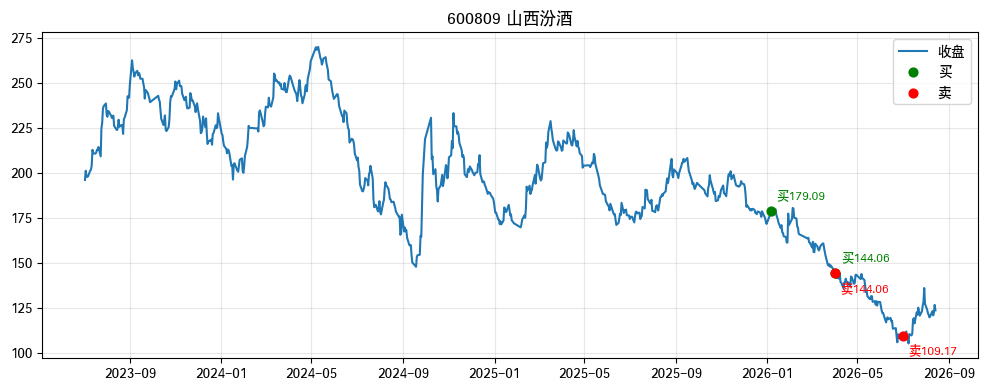

买入理由 2026-01-05 综合第9名 PE20.6 PB5.57 股息2.03% ROE27.1% Beta0.76 TTM增速-15.1% 市值2159亿
买入理由 2026-04-01 综合第7名 PE16.8 PB4.54 股息2.49% ROE27.1% Beta0.71 TTM增速-15.1% 市值1761亿
买2026-01-06@179.09 卖2026-04-02@144.06 季度全卖 收益-19.63%
买2026-04-02@144.06 卖2026-07-02@109.17 季度全卖 收益-24.29%
合计: 投入32315 收回25300 总收益-21.71%
---


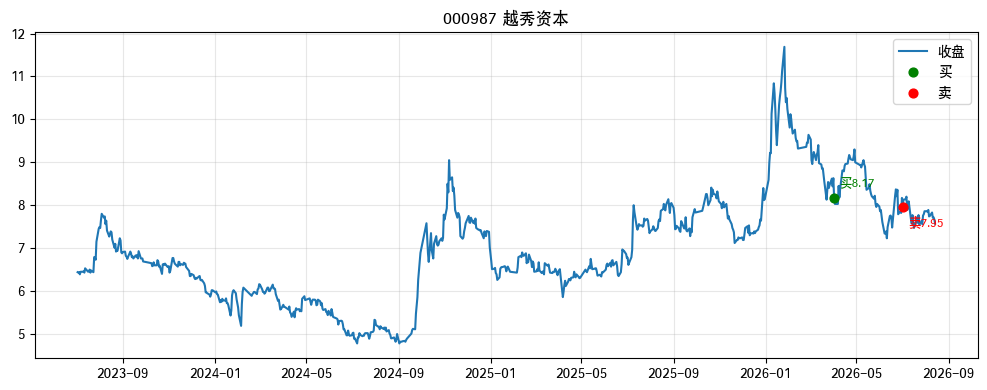

买入理由 2026-04-01 综合第19名 PE11.7 PB1.32 股息1.04% ROE11.2% Beta1.17 TTM增速79.2% 市值433亿
买2026-04-02@8.17 卖2026-07-02@7.95 季度全卖 收益-1.34%
合计: 投入22059 收回21763 总收益-1.34%
---


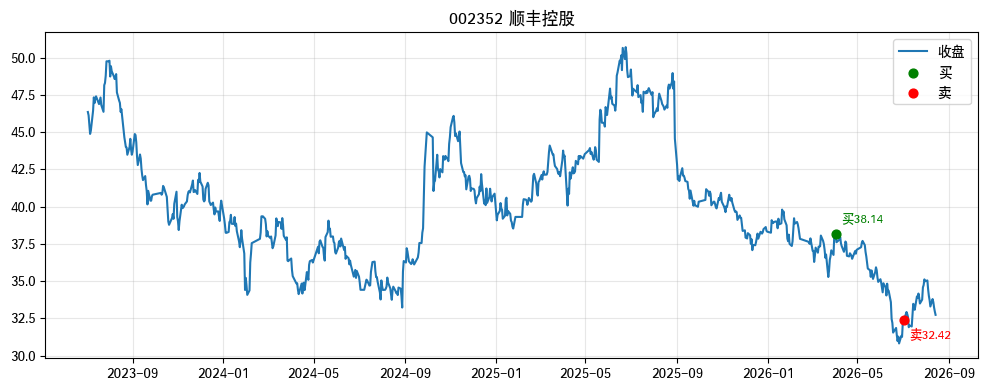

买入理由 2026-04-01 综合第15名 PE17.3 PB1.95 股息1.21% ROE11.3% Beta0.76 TTM增速9.3% 市值1920亿
买2026-04-02@38.14 卖2026-07-02@32.42 季度全卖 收益-14.05%
合计: 投入19070 收回16390 总收益-14.05%
---


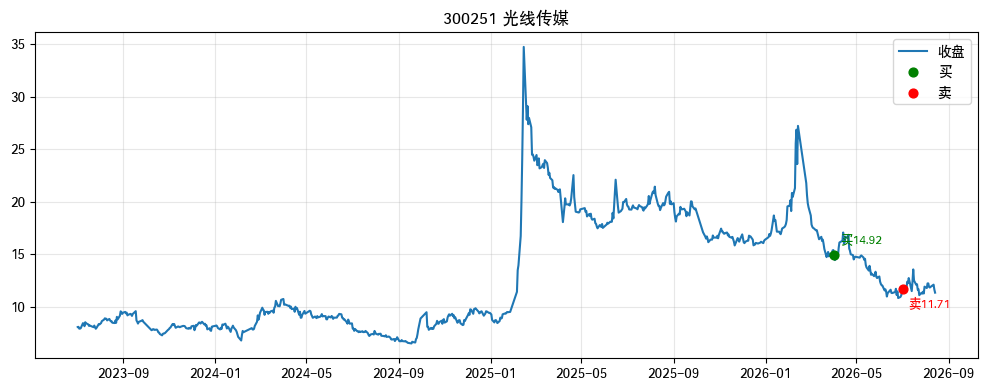

买入理由 2026-04-01 综合第10名 PE19.7 PB4.21 股息1.30% ROE21.3% Beta0.97 TTM增速349.3% 市值452亿
买2026-04-02@14.92 卖2026-07-02@11.71 季度全卖 收益-20.67%
合计: 投入22380 收回17753 总收益-20.67%
---


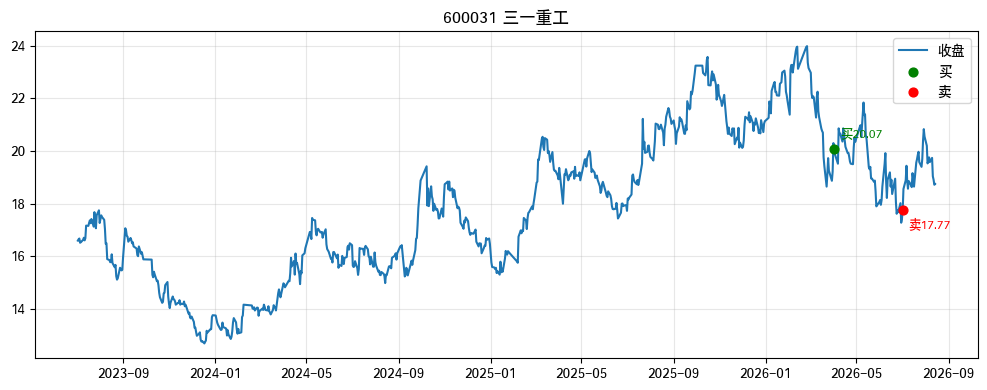

买入理由 2026-04-01 综合第16名 PE20.5 PB2.34 股息1.53% ROE11.5% Beta1.01 TTM增速41.2% 市值1720亿
买2026-04-02@20.07 卖2026-07-02@17.77 季度全卖 收益-11.53%
合计: 投入22077 收回19531 总收益-11.53%
---


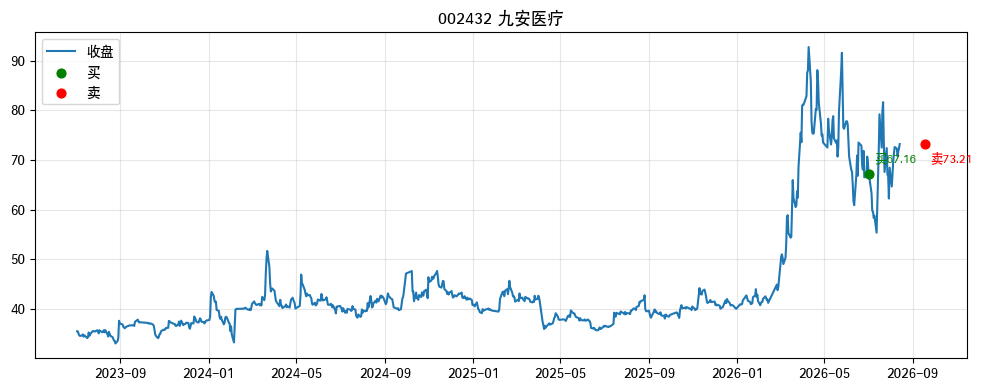

买入理由 2026-07-01 综合第12名 PE14.1 PB1.5 股息2.37% ROE10.6% Beta0.99 TTM增速35.9% 市值323亿
买2026-07-02@67.16 卖2026-09-18@73.21 期末持有 收益9.01%
合计: 投入20148 收回21963 总收益9.01%
---


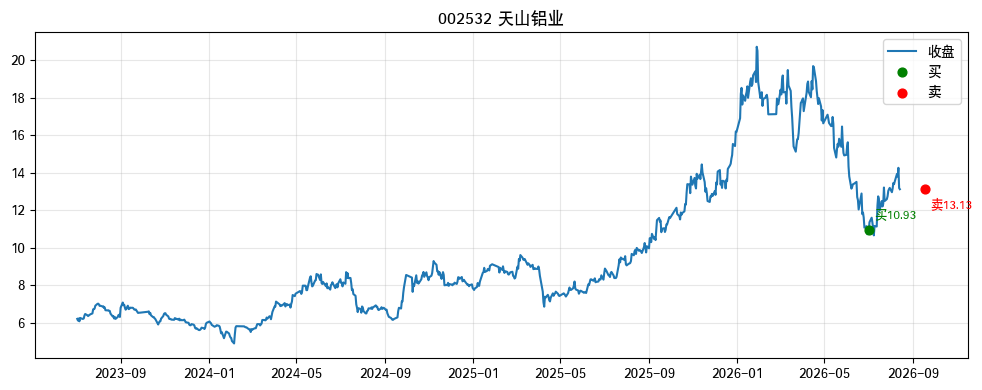

买入理由 2026-07-01 综合第16名 PE8.4 PB1.6 股息2.31% ROE19.1% Beta1.27 TTM增速24.7% 市值501亿
买2026-07-02@10.93 卖2026-09-18@13.13 期末持有 收益22.60%
合计: 投入19674 收回24120 总收益22.60%
---


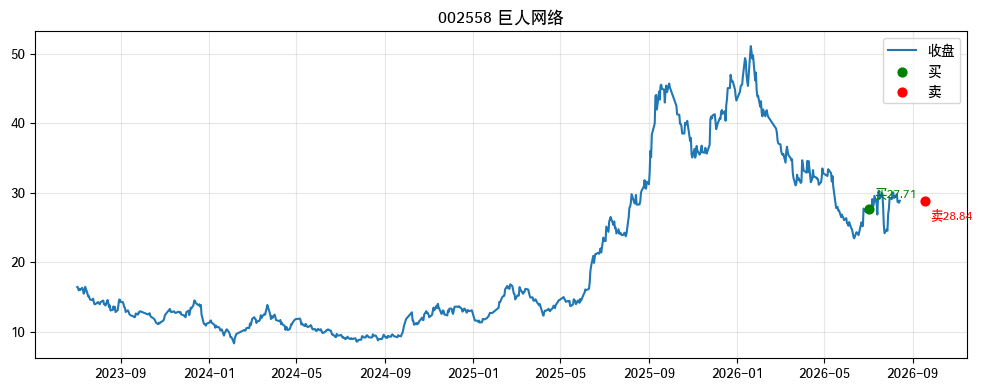

买入理由 2026-07-01 综合第20名 PE16.5 PB2.52 股息0.68% ROE15.2% Beta1.1 TTM增速75.1% 市值411亿
买2026-07-02@27.71 卖2026-09-18@28.84 期末持有 收益4.08%
合计: 投入19397 收回20188 总收益4.08%
---


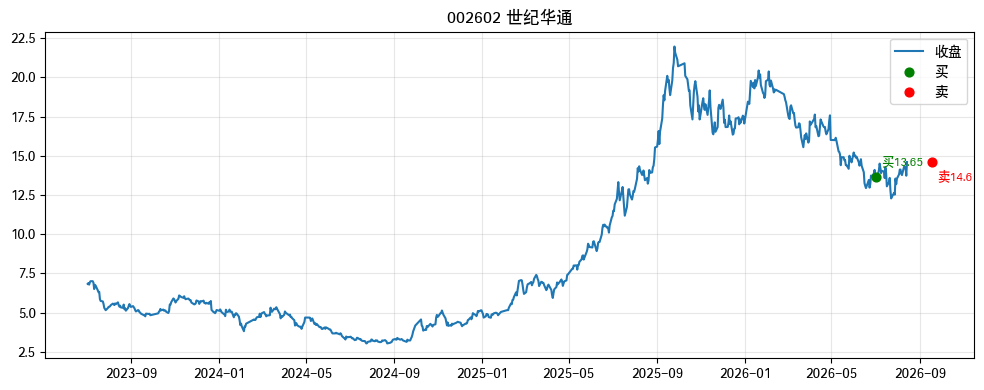

买入理由 2026-07-01 综合第13名 PE16.1 PB3.13 股息0.44% ROE19.4% Beta0.84 TTM增速228.7% 市值1012亿
买2026-07-02@13.65 卖2026-09-18@14.6 期末持有 收益6.96%
合计: 投入19110 收回20440 总收益6.96%
---


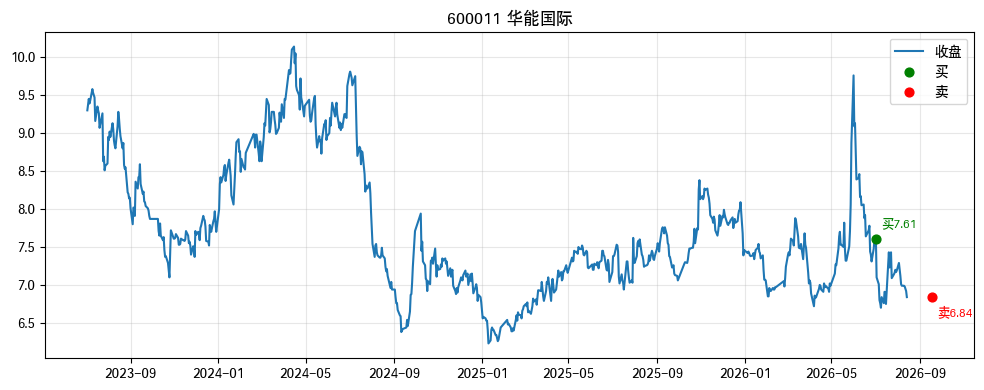

买入理由 2026-07-01 综合第4名 PE8.6 PB0.89 股息5.27% ROE10.3% Beta0.67 TTM增速32.4% 市值1191亿
买2026-07-02@7.61 卖2026-09-18@6.84 期末持有 收益-5.91%
合计: 投入19786 收回18616 总收益-5.91%
---


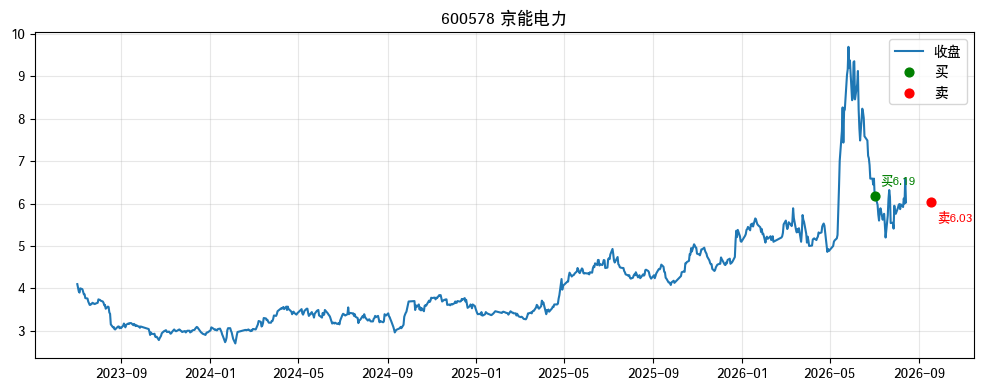

买入理由 2026-07-01 综合第9名 PE12.4 PB1.48 股息1.82% ROE11.9% Beta0.9 TTM增速49.5% 市值441亿
买2026-07-02@6.19 卖2026-09-18@6.03 期末持有 收益-0.39%
合计: 投入19808 收回19731 总收益-0.39%
---


In [24]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Hei', 'Heiti TC', 'STHeiti', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

for code in tr['code'].unique():
    rows = tr[tr['code'] == code].sort_values('buy_date')
    m = load_market(code, qfq=True).loc['2023-07-01':HARD_END]
    raw = load_market(code).loc['2023-07-01':HARD_END]
    fac = {k: float(v) for k, v in (m['close'] / raw['close']).items()}
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(m.index, m['close'])
    bp = [rows.loc[i, 'buy_price'] * fac.get(pd.Timestamp(rows.loc[i, 'buy_date']), np.nan) for i in rows.index]
    sp = [rows.loc[i, 'sell_price'] * fac.get(pd.Timestamp(rows.loc[i, 'sell_date']), np.nan) for i in rows.index]
    ax.scatter(pd.to_datetime(rows['buy_date']), bp, color='g', s=40, zorder=3)
    ax.scatter(pd.to_datetime(rows['sell_date']), sp, color='r', s=40, zorder=3)
    for _, r in rows.iterrows():
        ax.annotate(f"买{r['buy_price']}", (pd.Timestamp(r['buy_date']), r['buy_price'] * fac.get(pd.Timestamp(r['buy_date']), np.nan)),
                    textcoords='offset points', xytext=(4, 8), color='g', fontsize=9)
        ax.annotate(f"卖{r['sell_price']}", (pd.Timestamp(r['sell_date']), r['sell_price'] * fac.get(pd.Timestamp(r['sell_date']), np.nan)),
                    textcoords='offset points', xytext=(4, -14), color='r', fontsize=9)
    ax.set_title(f"{code} {rows.iloc[0]['name']}（前复权）")
    ax.legend(['收盘(前复权)', '买', '卖']); ax.grid(alpha=.3); plt.tight_layout(); plt.show(); plt.close()
    for _, r in rows.drop_duplicates('buy_date').iterrows():
        cap = snapshot(r['code'], pd.Timestamp(r['signal'])).market_cap / 1e8
        yoy = r['qyoy'] * 100 if pd.notna(r['qyoy']) else float('nan')
        print(f"买入理由 {r['signal']} 综合第{r['rank']}名 PE{r['pe']} PB{r['pb']} "
              f"股息{r['dp']*100:.2f}% ROE{r['roe']*100:.1f}% "
              f"Beta{r['beta']} TTM增速{yoy:.1f}% 市值{cap:.0f}亿")
    tb = rows['buy_amt'].sum(); ts = rows['sell_proceeds'].sum()
    for _, r in rows.iterrows():
        ret = f"{r['ret']*100:.2f}%" if pd.notna(r['ret']) else '减仓(部分)'
        print(f"买{r['buy_date']}@{r['buy_price']} 卖{r['sell_date']}@{r['sell_price']} {r['note']} 收益{ret}")
    print(f"合计: 投入{tb:.0f} 收回{ts:.0f} 总收益{ts/tb*100-100:.2f}%")
    print('---')
